In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

In [14]:
df_test=pd.read_csv(r"F:\playground-series-s6e6\test.csv")
df_test.head()

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population
0,577347,120.719779,23.924249,23.668066,21.951680,21.086183,20.180032,19.202124,0.429042,G/K,Red_Sequence
1,577348,219.414419,42.171651,24.902933,22.338822,20.732163,19.860330,19.687691,0.867305,M,Red_Sequence
2,577349,173.568731,-1.756400,19.427591,18.474633,17.551314,16.570674,16.176765,0.224234,G/K,Blue_Cloud
3,577350,184.903993,-1.411074,23.121029,21.526855,20.670159,20.417633,20.699095,0.066507,G/K,Red_Sequence
4,577351,222.487816,15.381403,25.094282,22.643981,21.123173,19.439500,19.094158,0.977218,M,Red_Sequence


In [15]:
print("Dataset Shape")
df_test.shape

Dataset Shape


(247435, 11)

In [16]:
print("dataset columns")
df_test.columns.to_list()

dataset columns


['id',
 'alpha',
 'delta',
 'u',
 'g',
 'r',
 'i',
 'z',
 'redshift',
 'spectral_type',
 'galaxy_population']

In [17]:
print("Columns datatypes")
df_test.dtypes

Columns datatypes


id                     int64
alpha                float64
delta                float64
u                    float64
g                    float64
r                    float64
i                    float64
z                    float64
redshift             float64
spectral_type         object
galaxy_population     object
dtype: object

In [18]:
print("Total Missing values")
df_test.isnull().sum()

Total Missing values


id                   0
alpha                0
delta                0
u                    0
g                    0
r                    0
i                    0
z                    0
redshift             0
spectral_type        0
galaxy_population    0
dtype: int64

In [19]:
print("Duplicated Rows")
df_test.duplicated().sum()

Duplicated Rows


0

In [20]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247435 entries, 0 to 247434
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 247435 non-null  int64  
 1   alpha              247435 non-null  float64
 2   delta              247435 non-null  float64
 3   u                  247435 non-null  float64
 4   g                  247435 non-null  float64
 5   r                  247435 non-null  float64
 6   i                  247435 non-null  float64
 7   z                  247435 non-null  float64
 8   redshift           247435 non-null  float64
 9   spectral_type      247435 non-null  object 
 10  galaxy_population  247435 non-null  object 
dtypes: float64(8), int64(1), object(2)
memory usage: 20.8+ MB


In [21]:
num_cols=df_test.select_dtypes(include=np.number).columns

desc=df_test[num_cols].describe().T

desc["skew"]=df_test[num_cols].skew()
desc["kurtosis"]=df_test[num_cols].kurt()

display(desc)

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
id,247435.0,701064.000000,71428.476266,577347.000000,639205.500000,701064.000000,762922.500000,824781.000000,0.000000,-1.200000
alpha,247435.0,181.360629,96.213374,0.010959,132.023953,188.559428,231.690068,359.999724,-0.054166,-0.405874
delta,247435.0,21.853898,18.931367,-17.959259,2.527822,21.452023,37.061924,79.170436,0.173394,-1.121296
u,247435.0,22.442070,2.019044,13.902664,20.978208,22.569616,23.869689,27.835633,-0.113468,-0.511916
g,247435.0,21.009837,1.798633,13.374549,19.866076,21.469175,22.294539,27.173411,-0.631422,-0.275236
r,247435.0,19.965651,1.650949,10.390731,18.831805,20.431512,21.165467,25.291984,-0.666759,-0.424182
i,247435.0,19.381860,1.581880,10.034180,18.314240,19.632235,20.618391,24.567823,-0.489611,-0.459064
z,247435.0,19.043151,1.587103,10.632025,17.976477,19.196316,20.167750,25.700336,-0.325434,-0.422330
redshift,247435.0,0.724780,0.810582,-0.009968,0.183117,0.498598,0.882659,7.007179,2.283837,6.830636


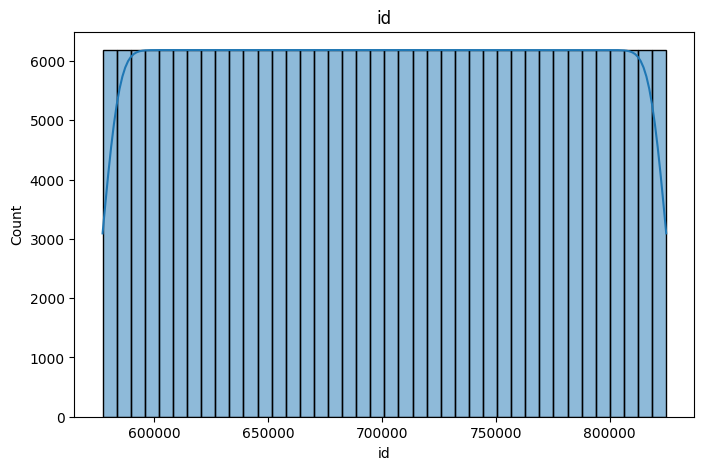

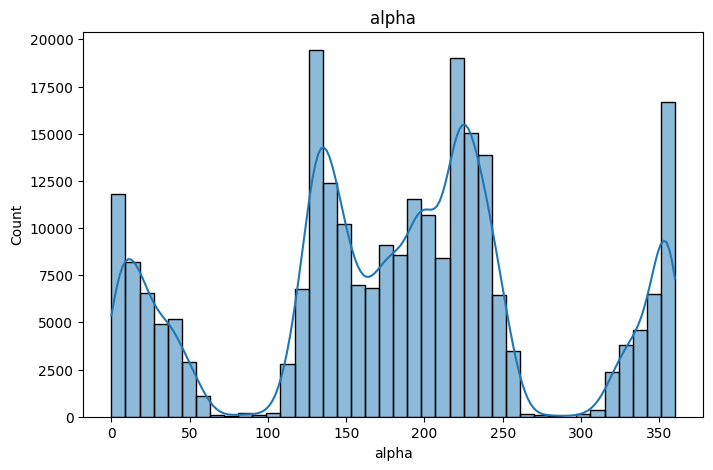

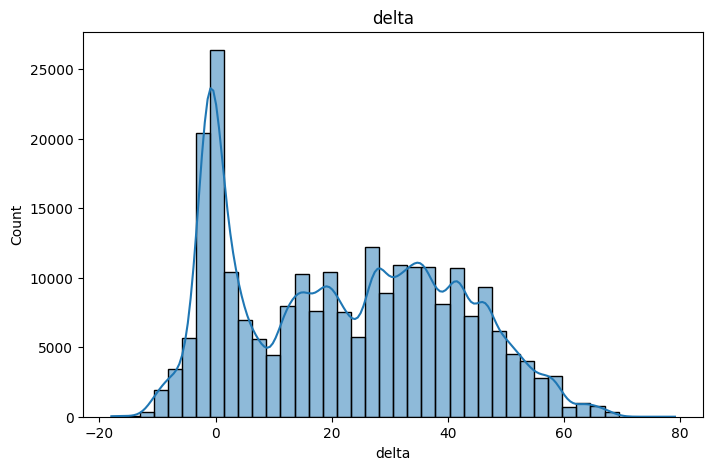

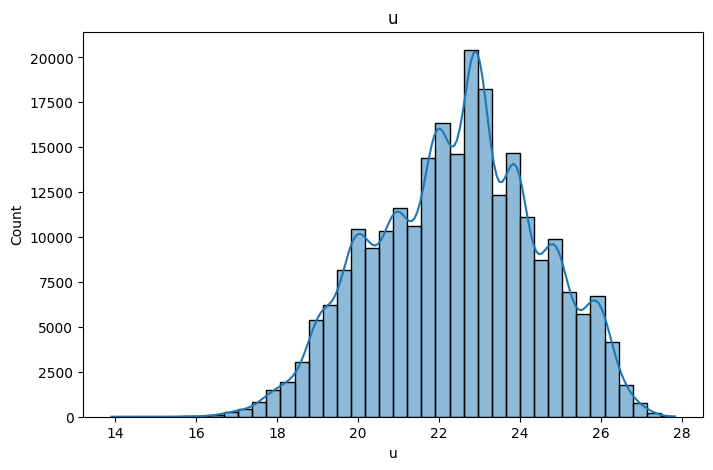

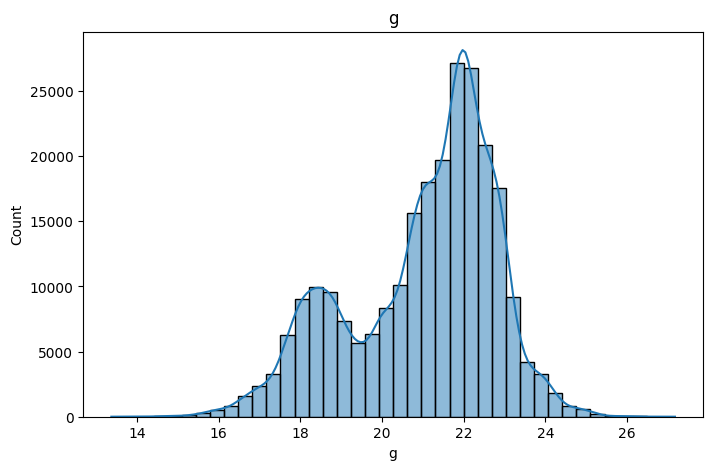

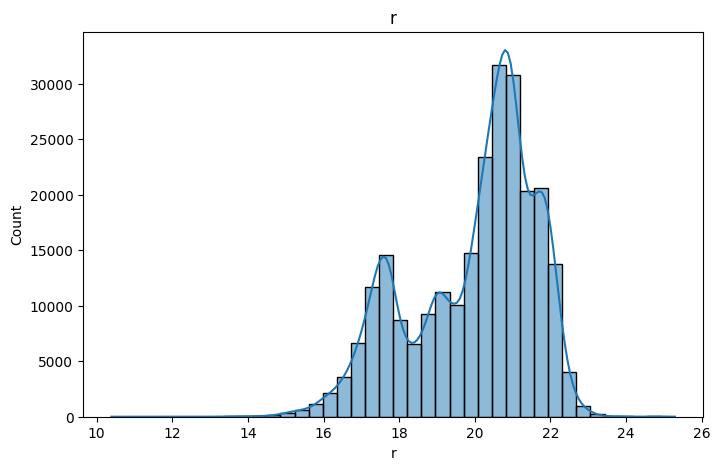

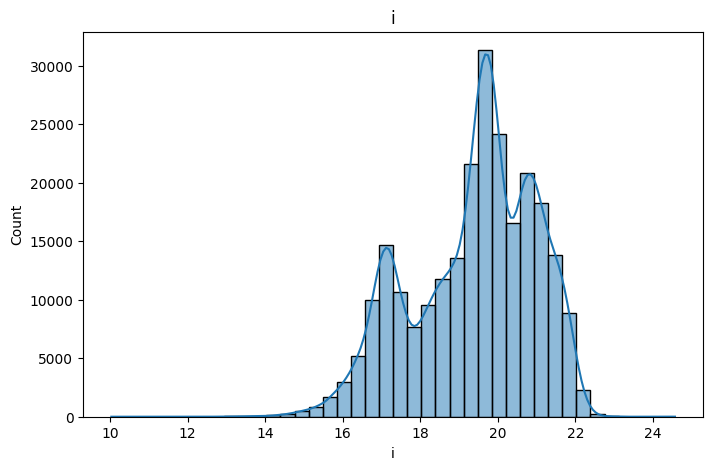

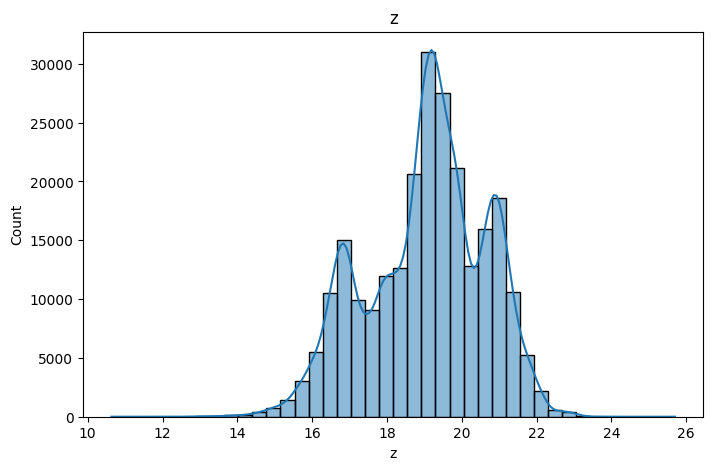

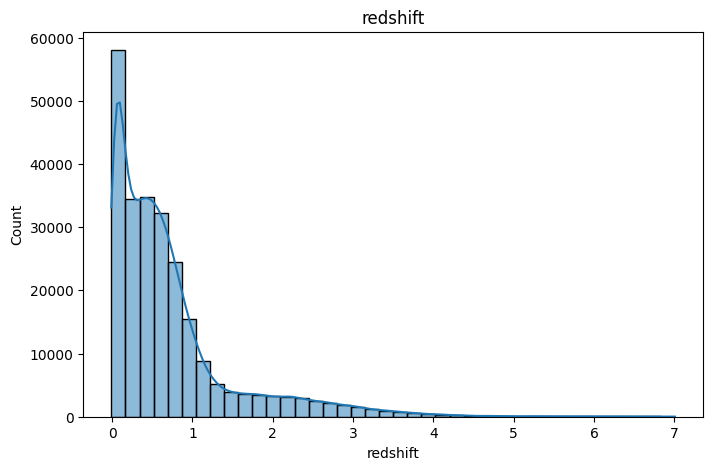

In [23]:
for col in num_cols:
    plt.figure(figsize=(8,5))

    sns.histplot(data=df_test[col],kde=True,bins=40)
    plt.title(col)
    plt.show()

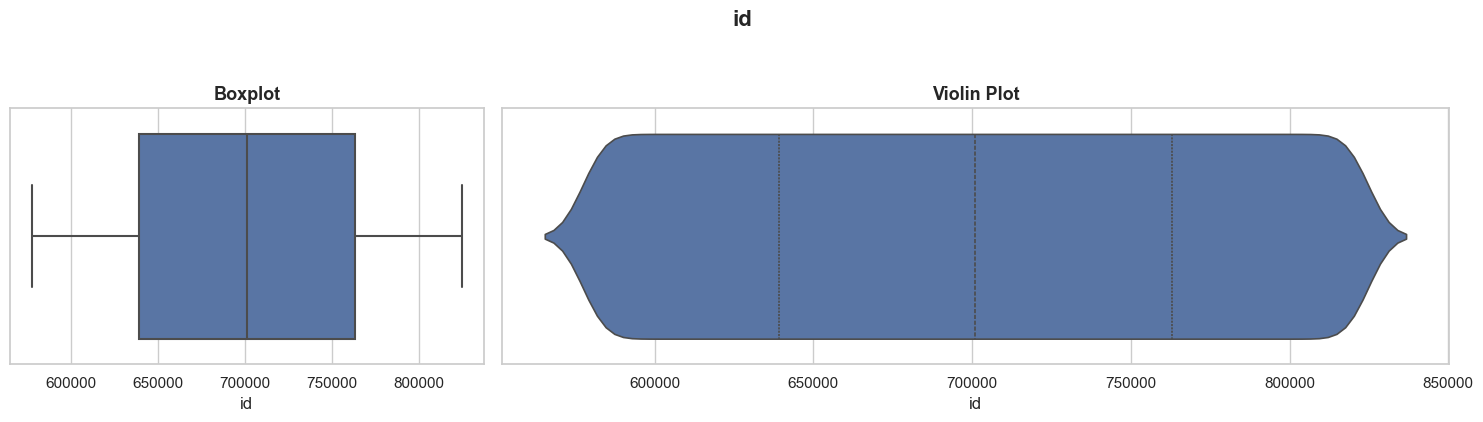

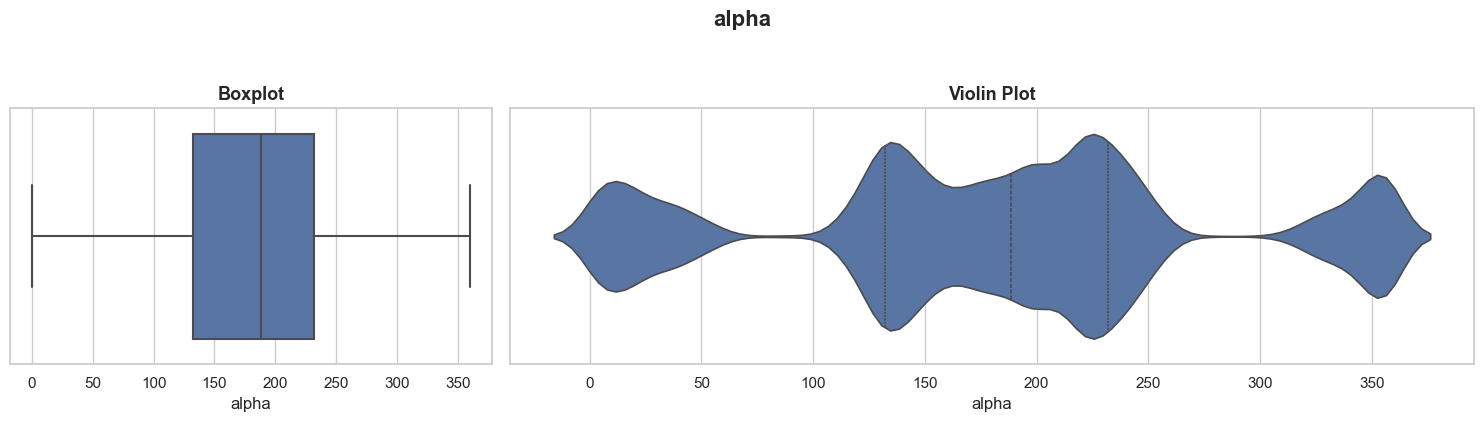

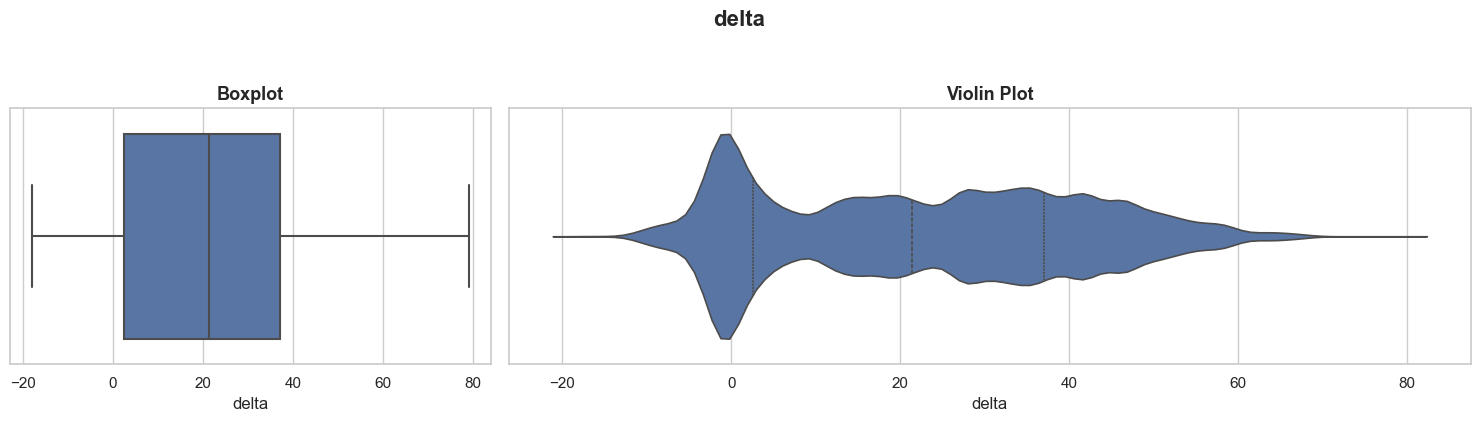

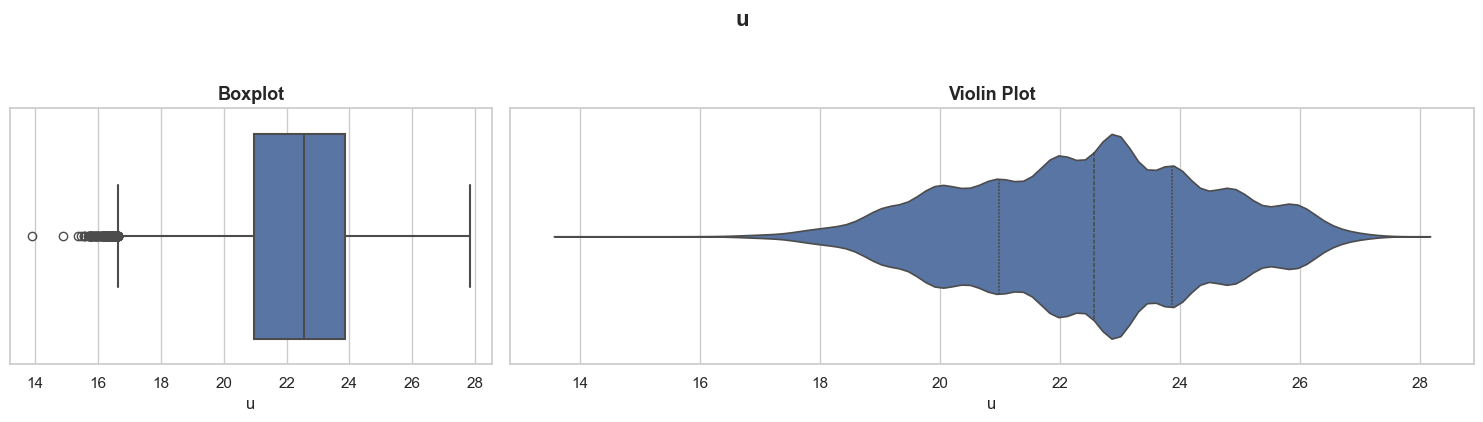

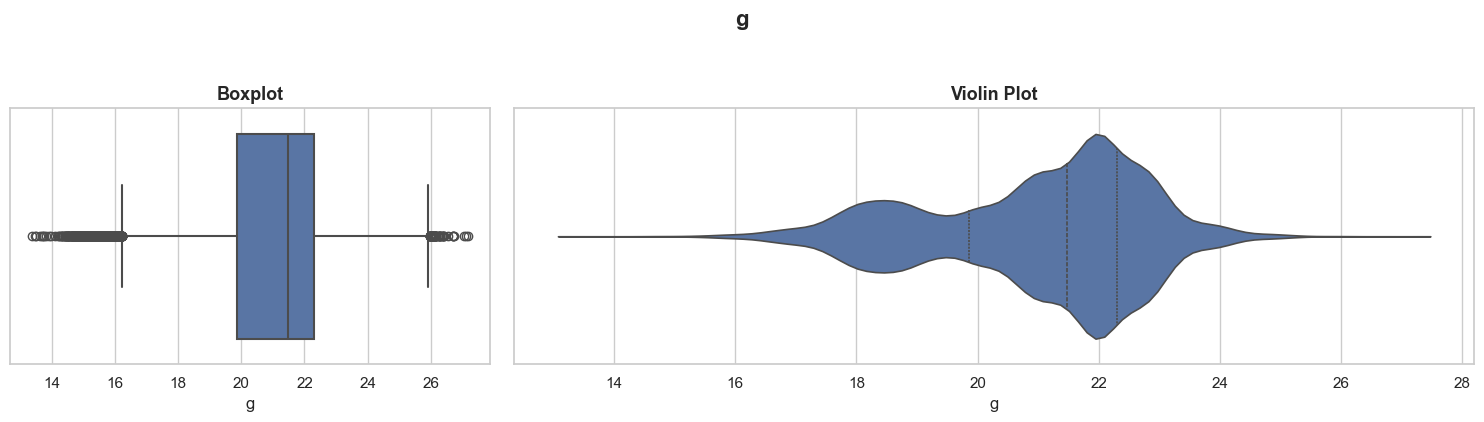

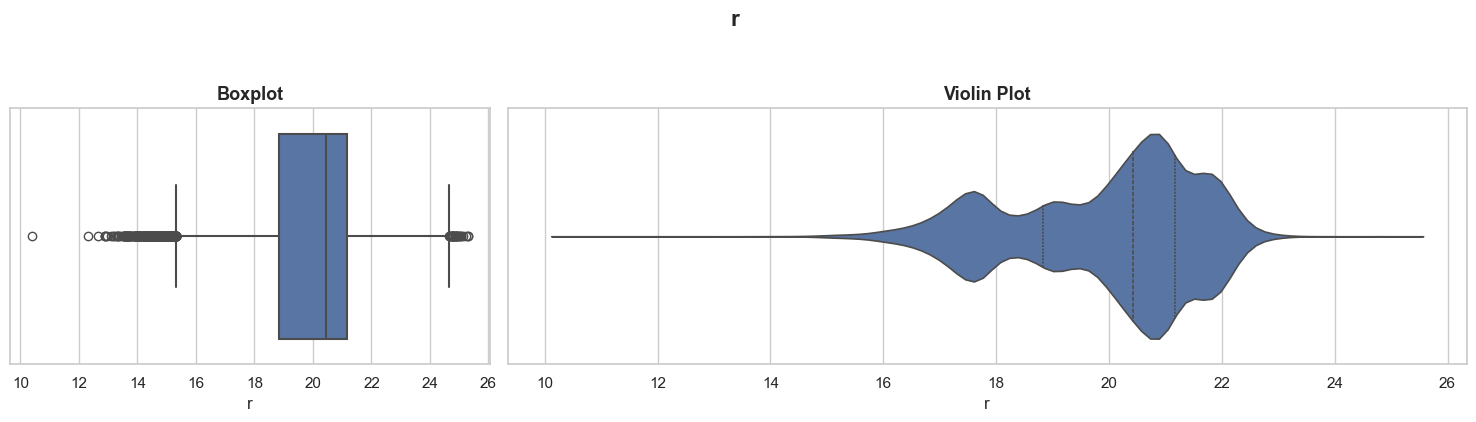

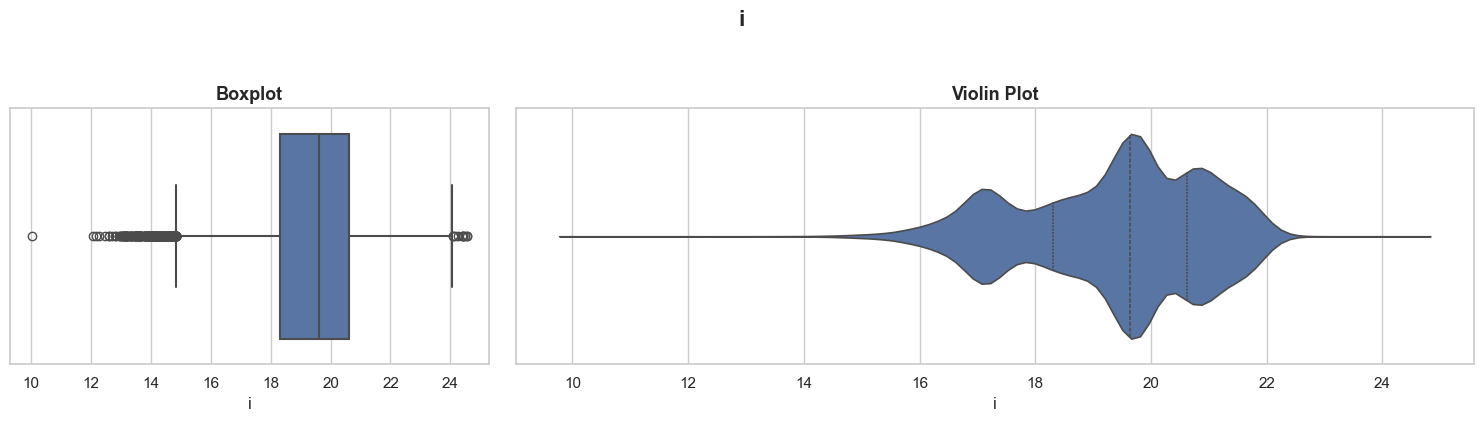

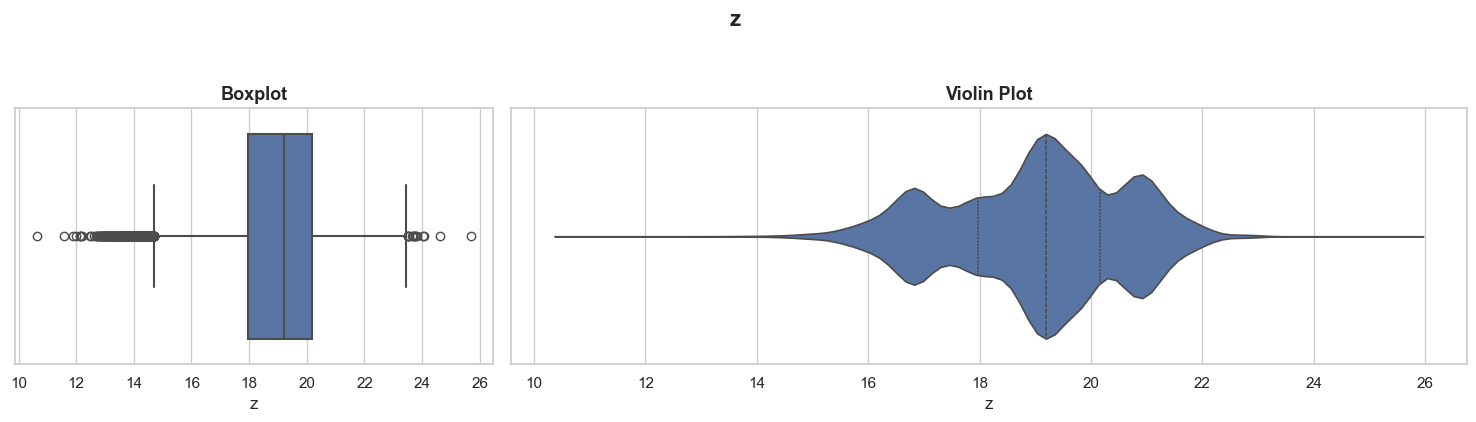

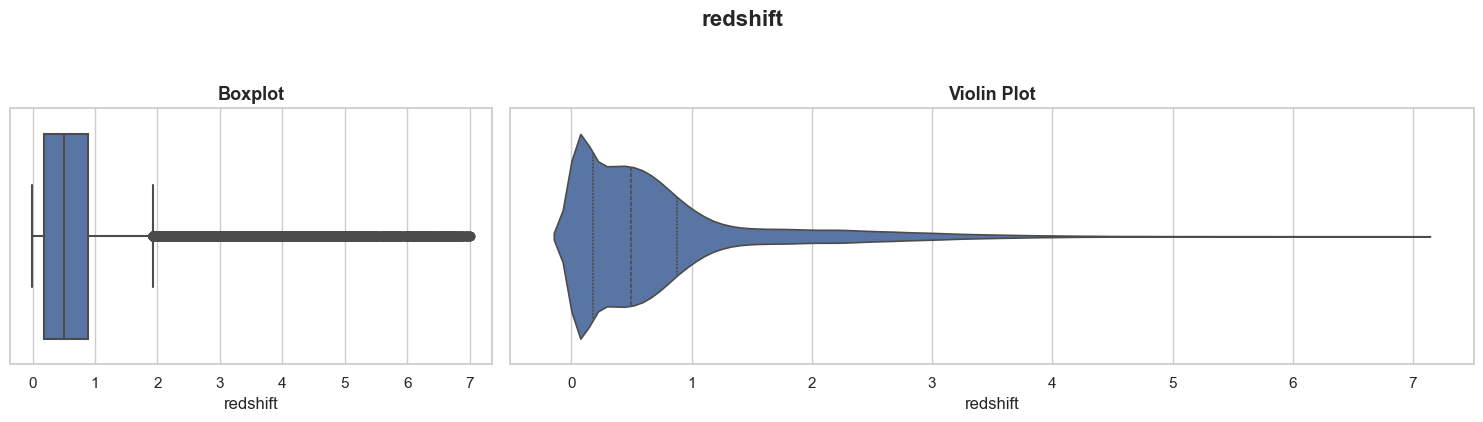

In [24]:
sns.set_theme(style="whitegrid",context="notebook")

for col in num_cols:

    fig, ax = plt.subplots(
        1, 2,
        figsize=(15, 4),
        gridspec_kw={"width_ratios": [1, 2]}
    )

    sns.boxplot(
        x=df_test[col],
        ax=ax[0],
        linewidth=1.5
    )

    sns.violinplot(
        x=df_test[col],
        ax=ax[1],
        inner="quartile",
        linewidth=1.2
    )

    ax[0].set_title(
        f"Boxplot",
        fontsize=13,
        fontweight="bold"
    )

    ax[1].set_title(
        f"Violin Plot",
        fontsize=13,
        fontweight="bold"
    )

    fig.suptitle(
        col,
        fontsize=16,
        fontweight="bold",
        y=1.05
    )

    plt.tight_layout()
    plt.show()

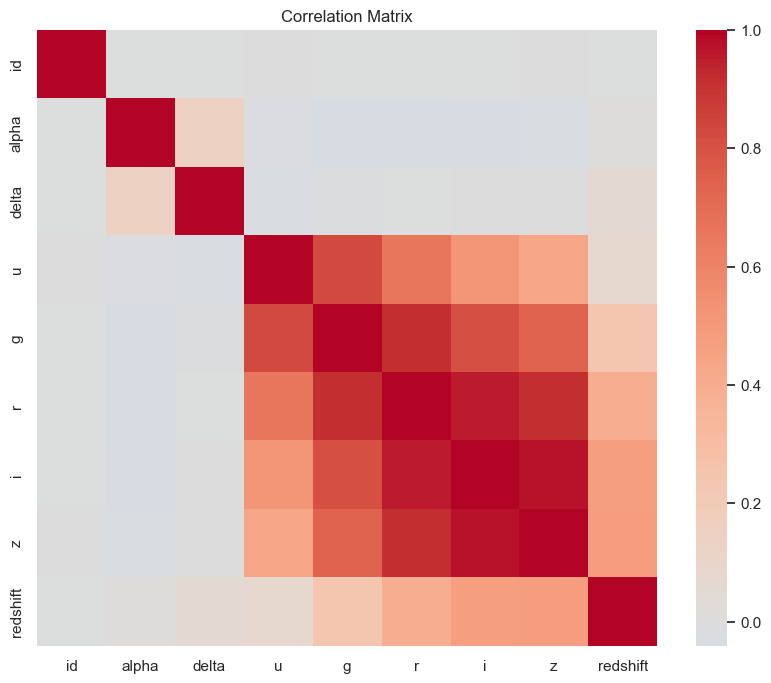

In [25]:
corr_matrix=df_test[num_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix,cmap="coolwarm",center=0)
plt.title("Correlation Matrix")
plt.show()

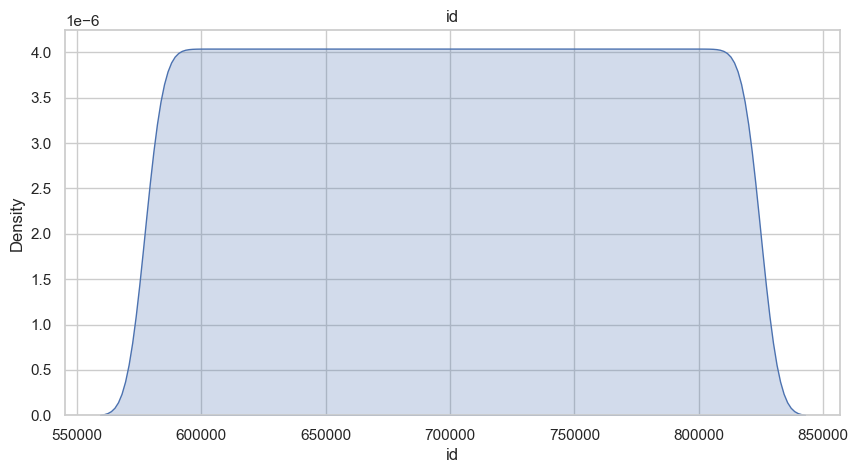

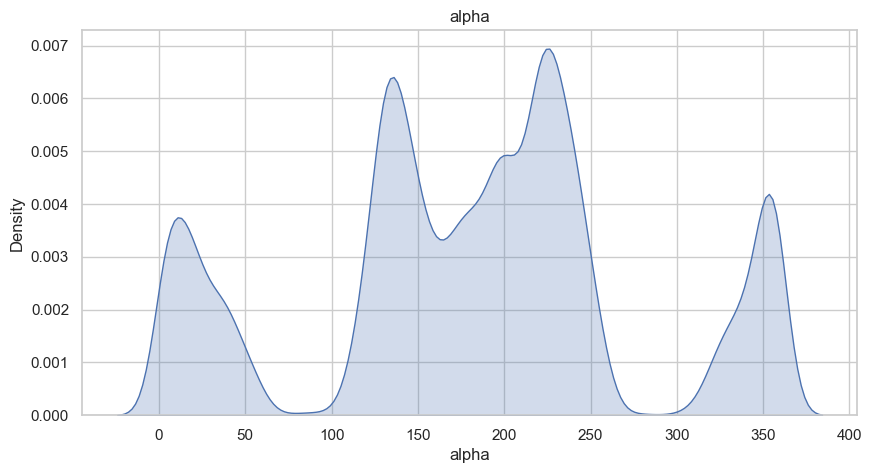

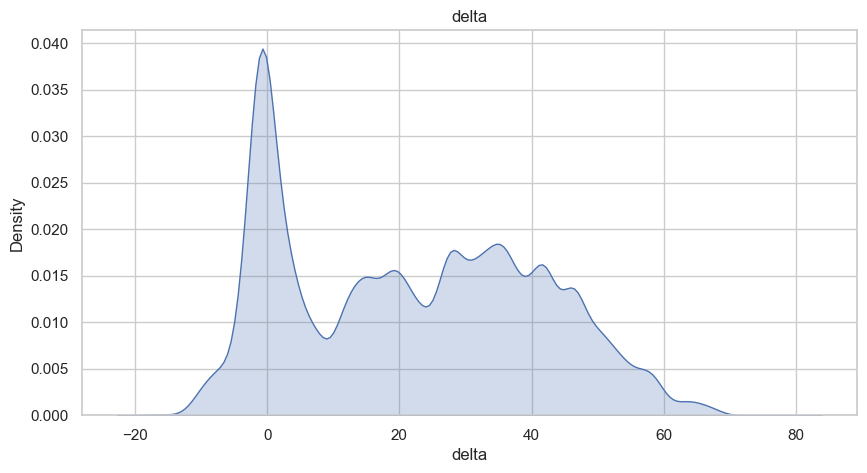

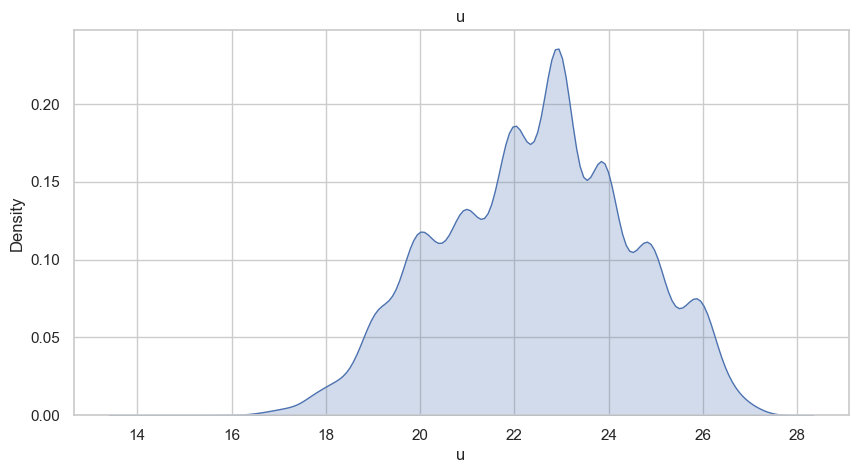

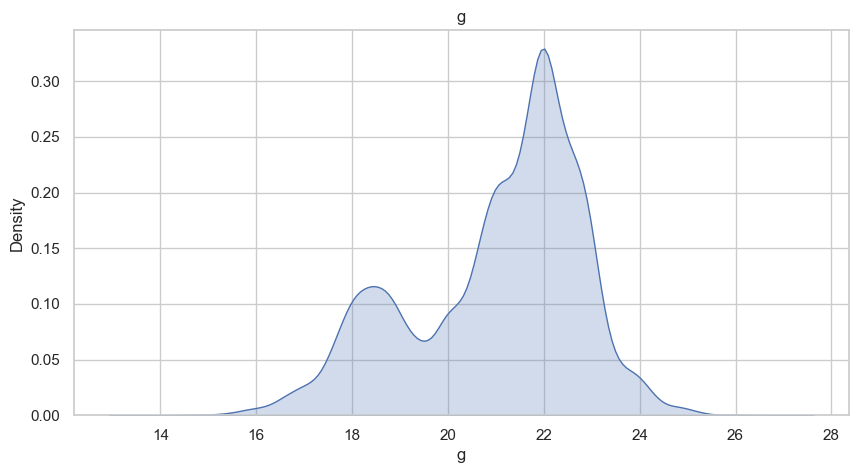

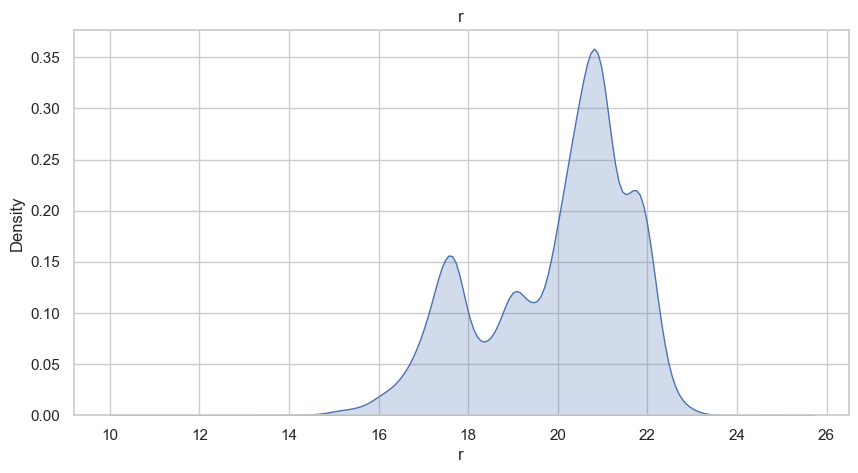

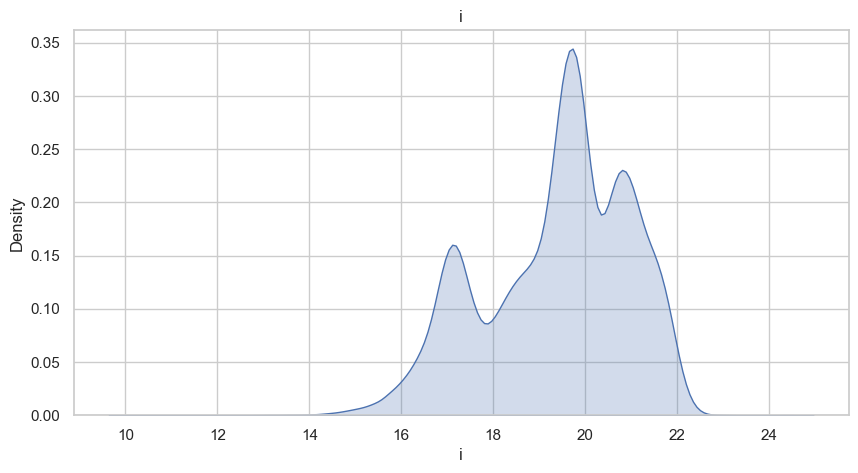

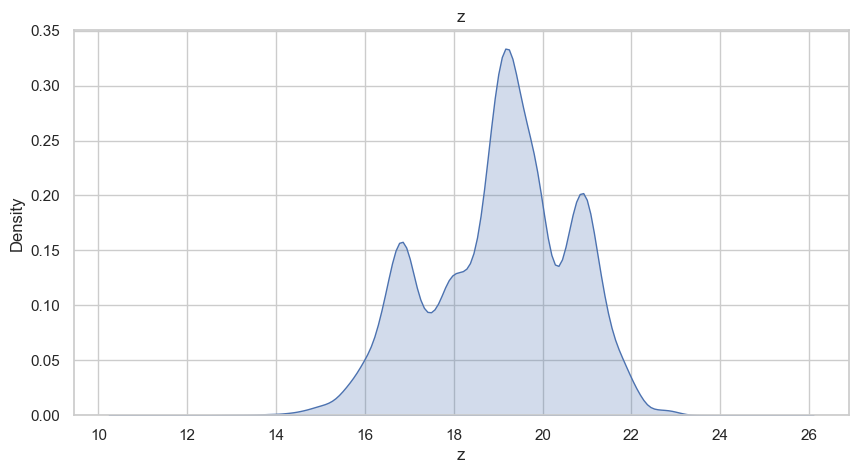

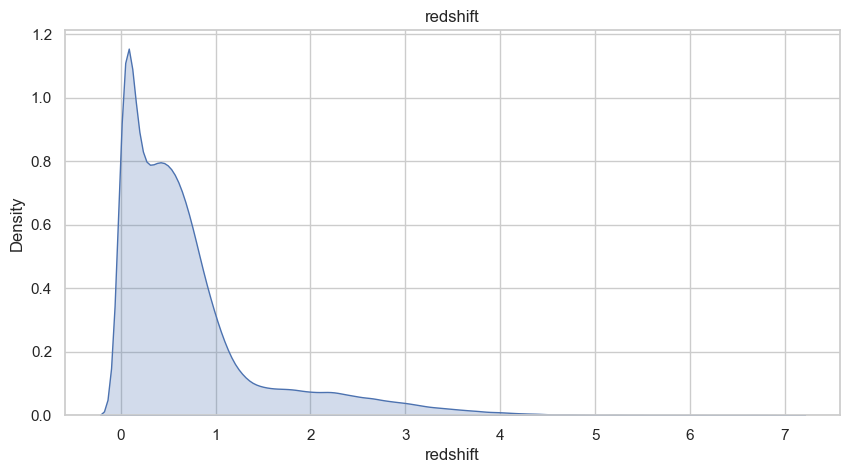

In [26]:
for col in num_cols:
    plt.figure(figsize=(10,5))
    sns.kdeplot(
        data=df_test,
        x=col,
        fill=True
    )
    plt.title(col)
    plt.show()

In [27]:
unique_df = pd.DataFrame({"Unique Values": df_test.nunique(),"Dtype": df_test.dtypes})
display(unique_df.sort_values("Unique Values",ascending=False))

,Unique Values,Dtype
id,247435,int64
u,247435,float64
g,247435,float64
r,247435,float64
i,247435,float64
z,247435,float64
redshift,246031,float64
delta,201819,float64
alpha,200893,float64
spectral_type,4,object


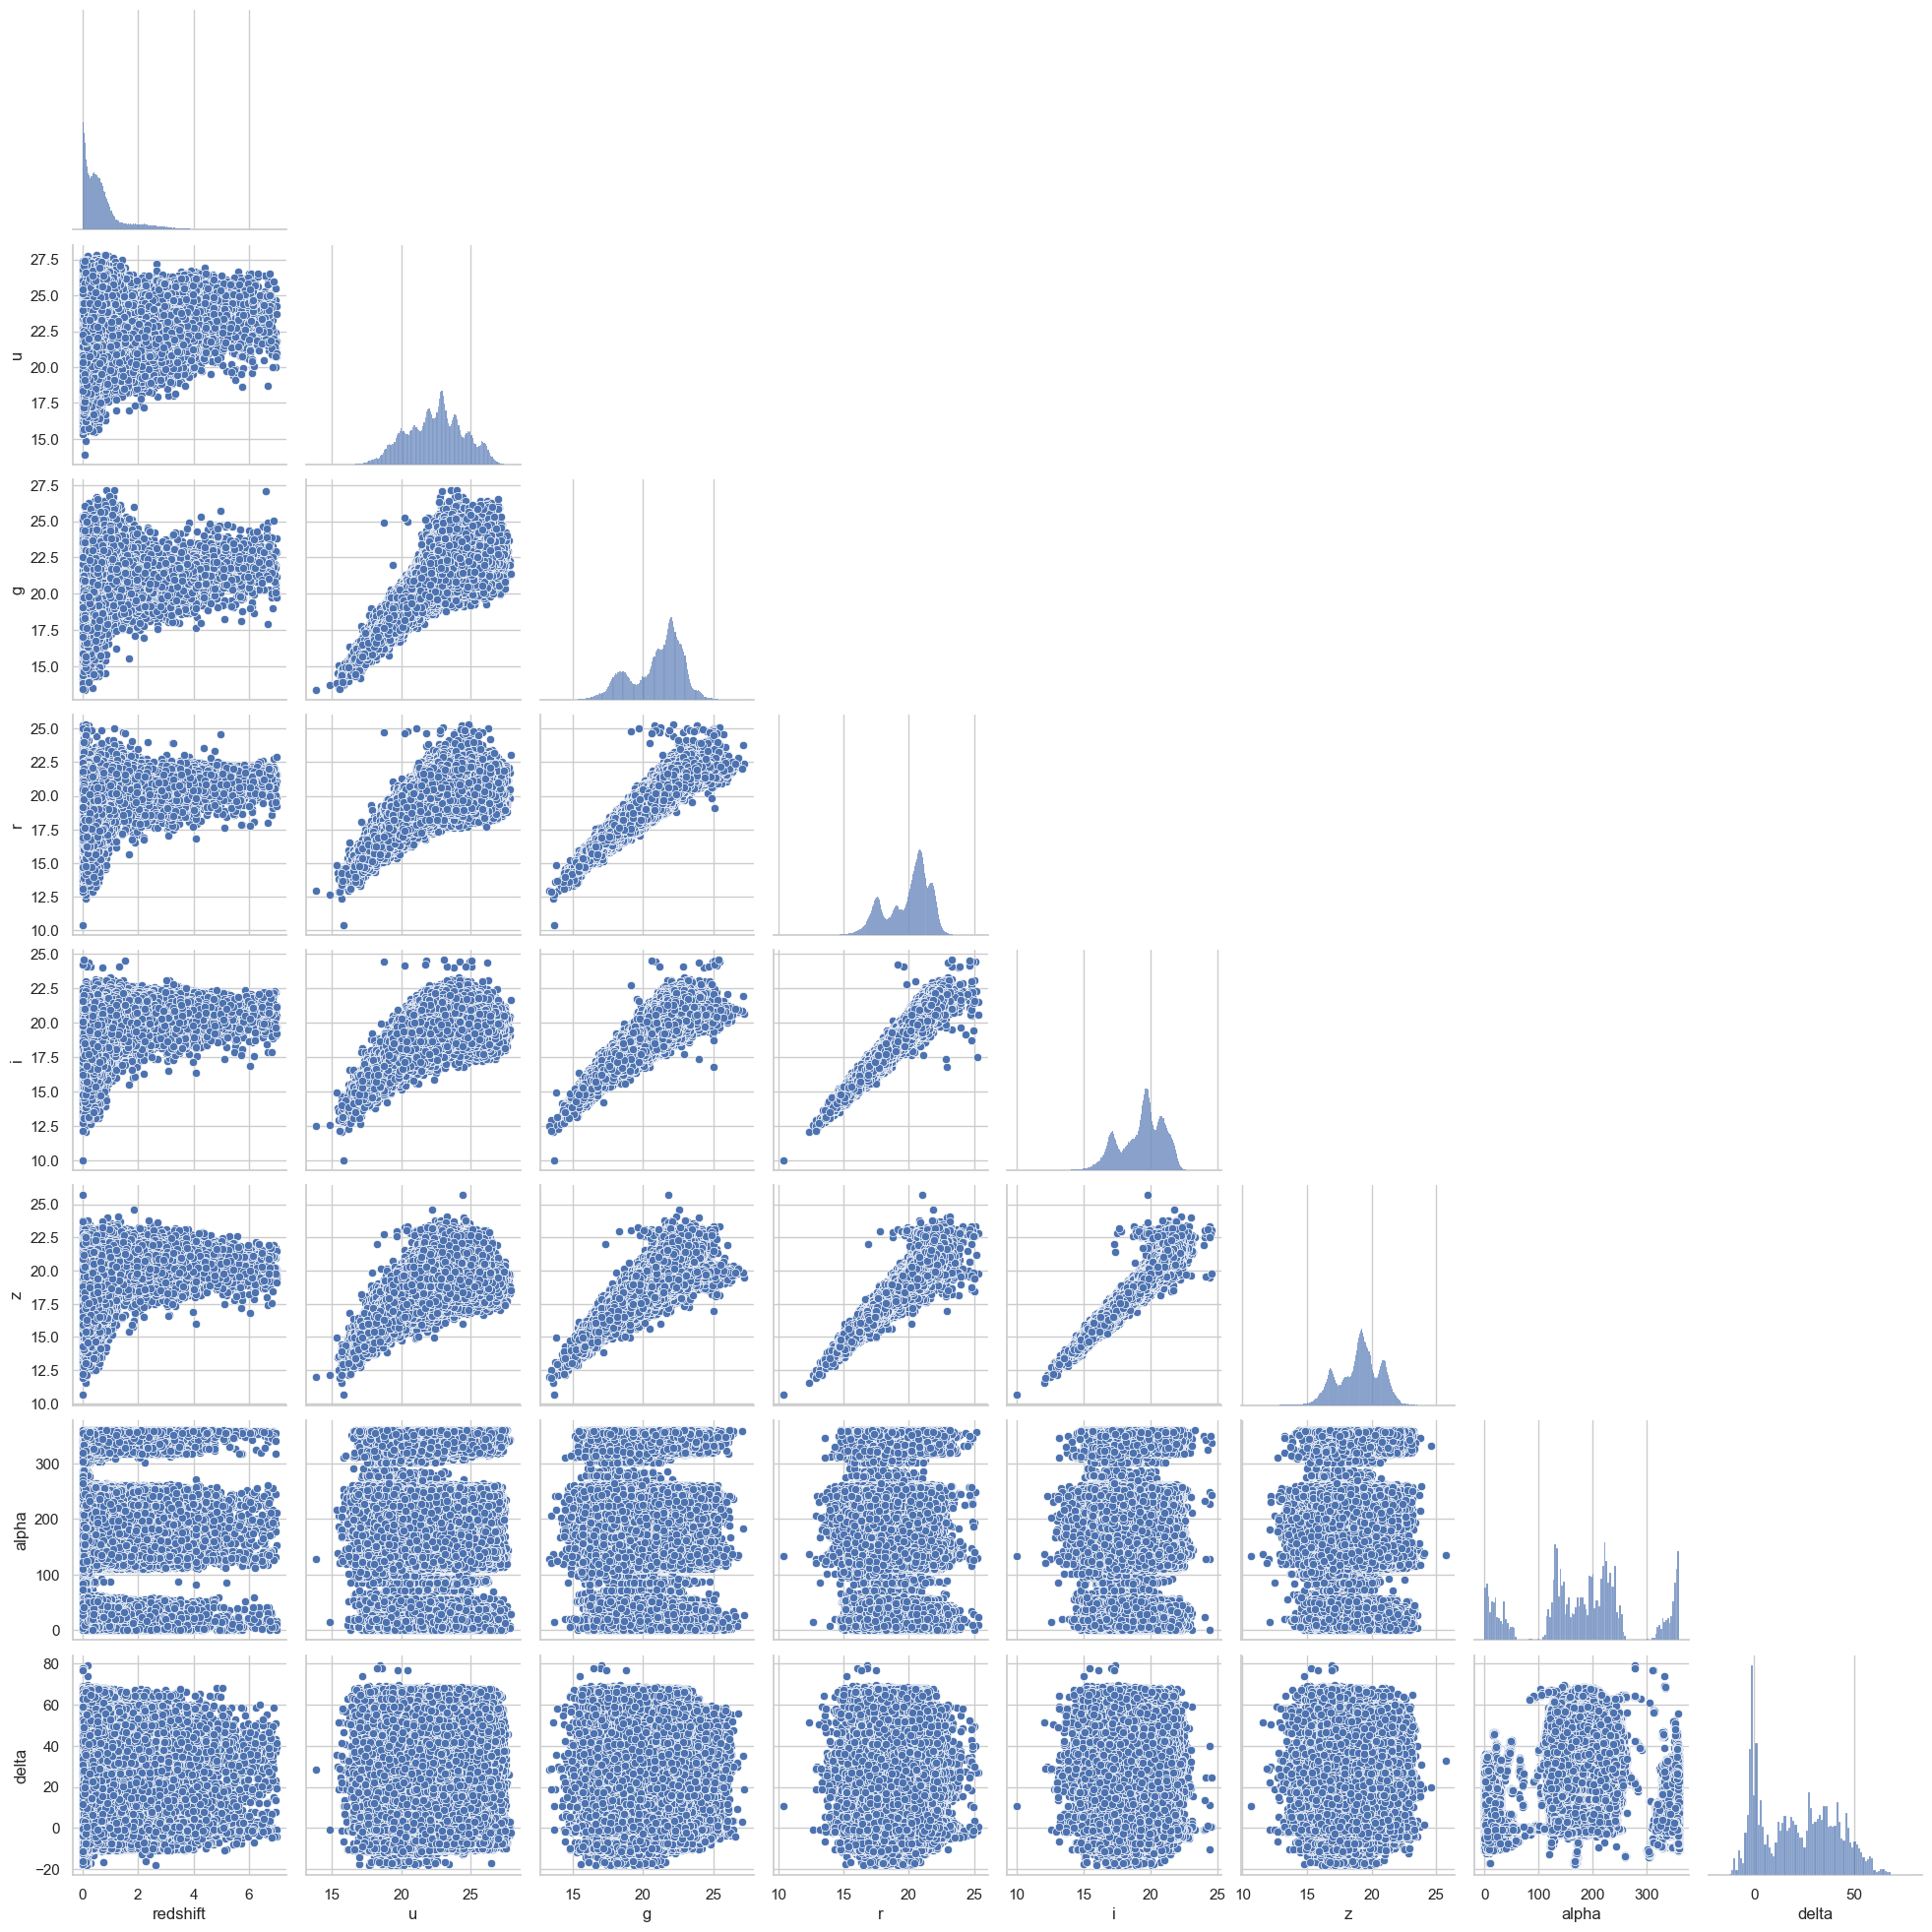

In [29]:
sns.pairplot(
    df_test,
    vars=[
        "redshift",
        "u",
        "g",
        "r",
        "i",
        "z",
        "alpha",
        "delta"
    ],
    corner=True
)
plt.show()

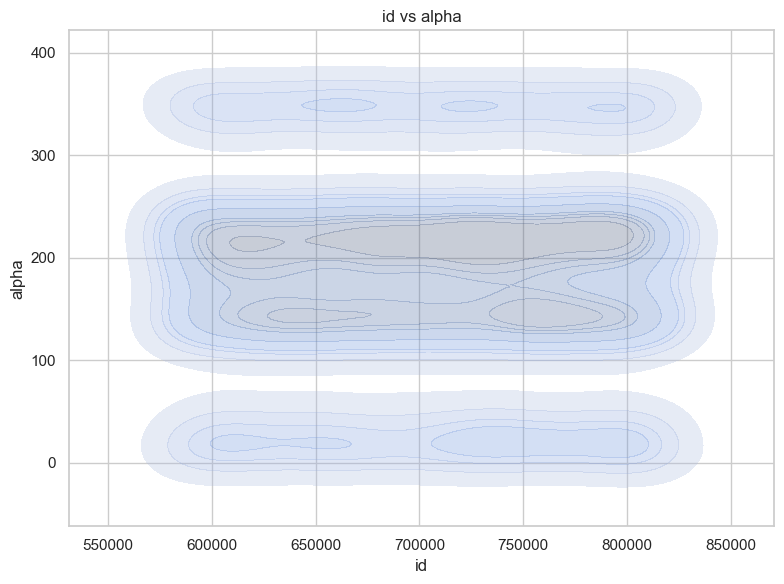

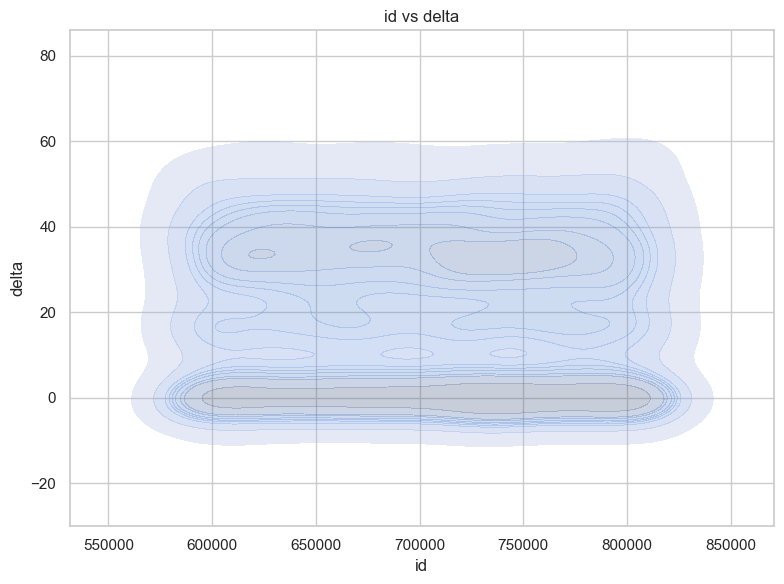

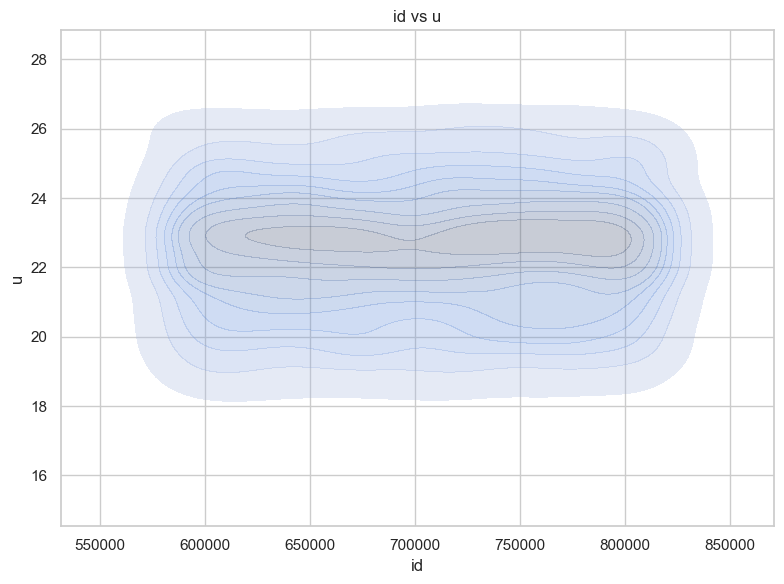

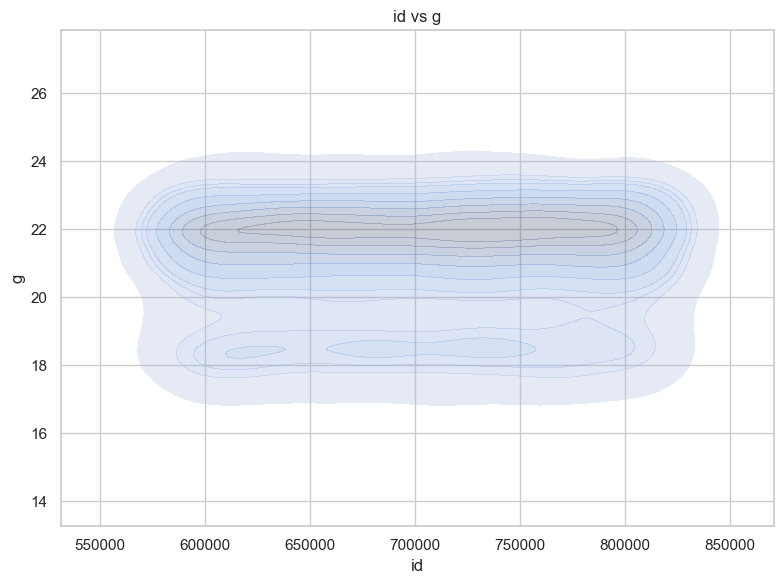

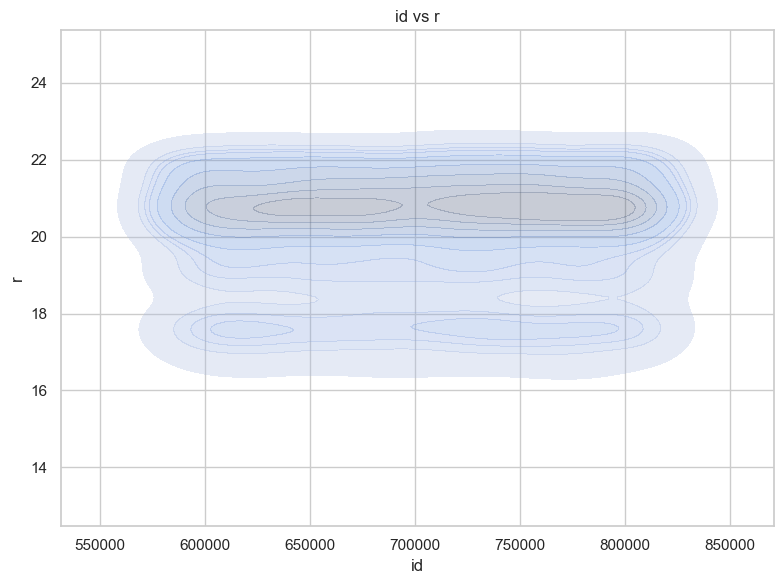

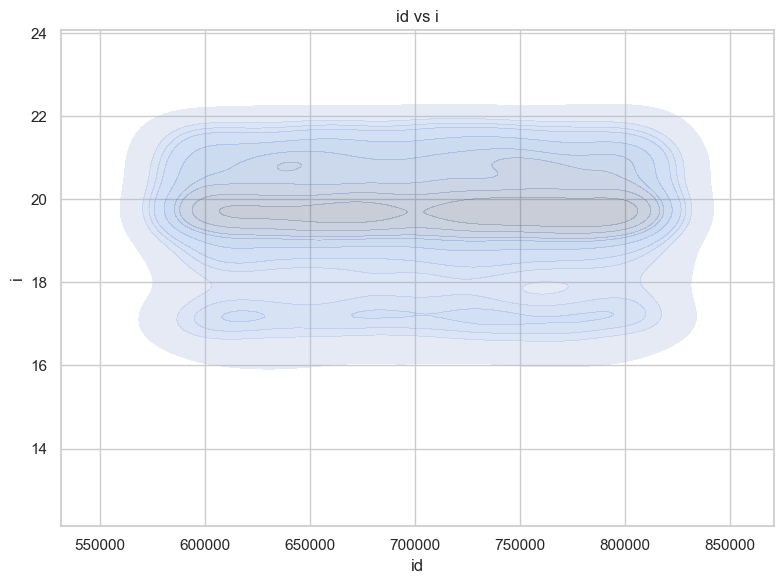

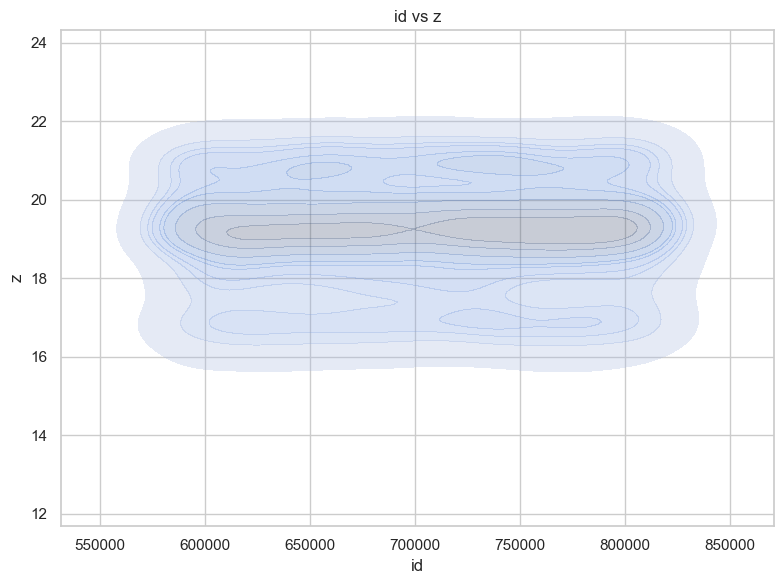

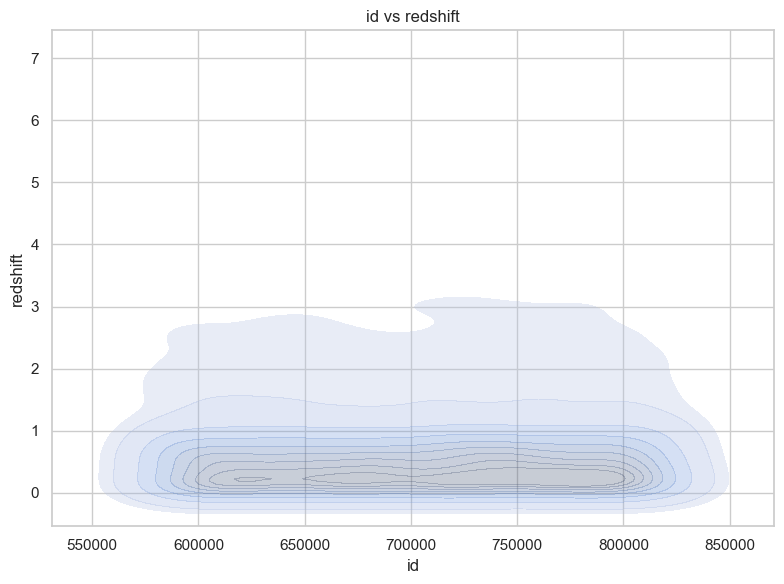

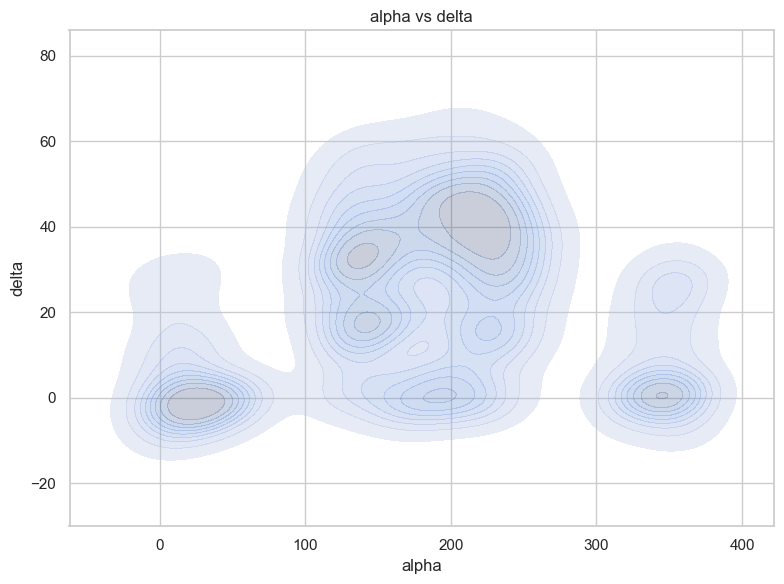

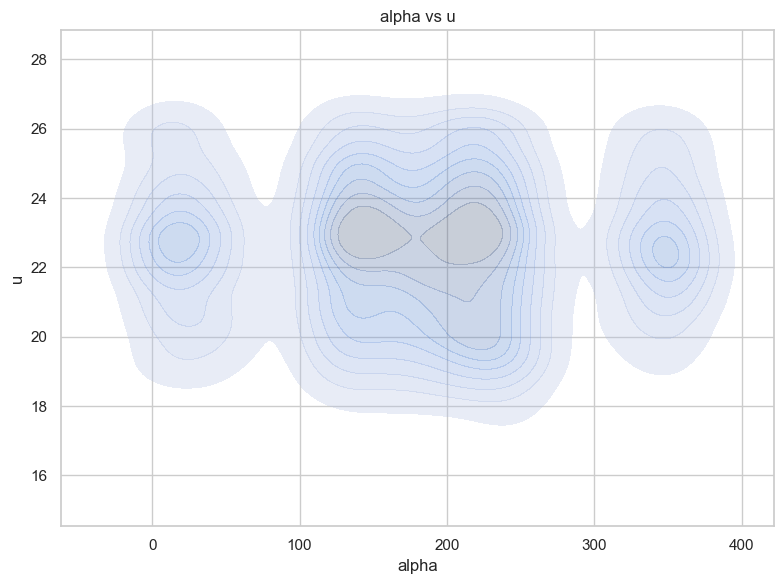

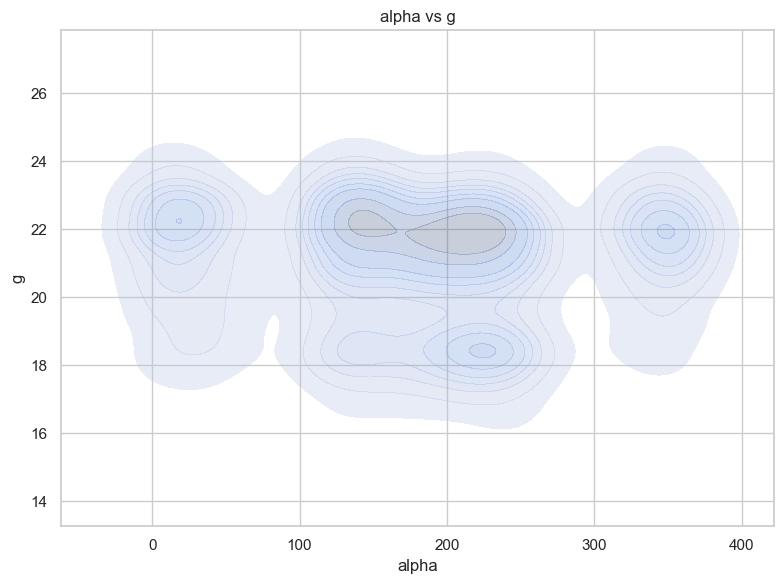

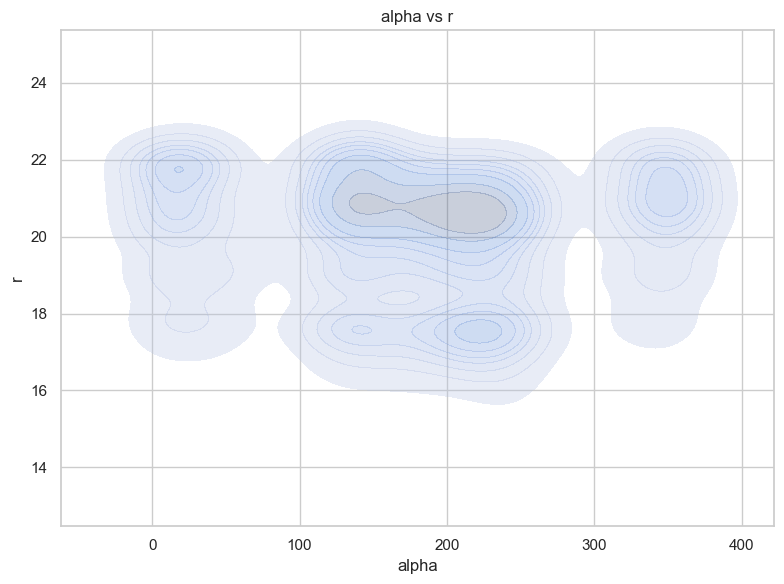

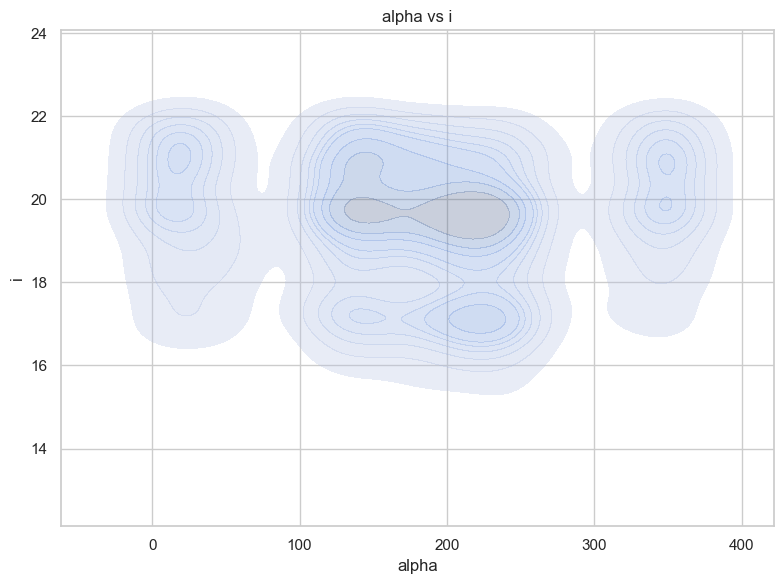

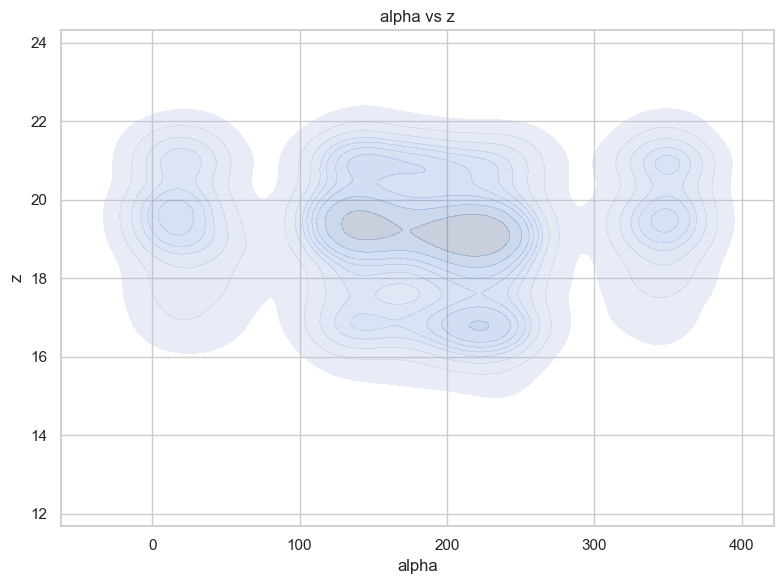

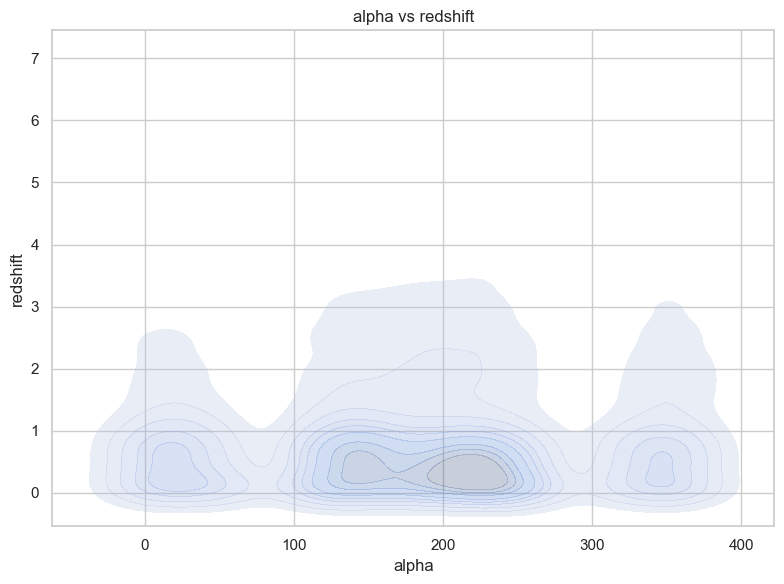

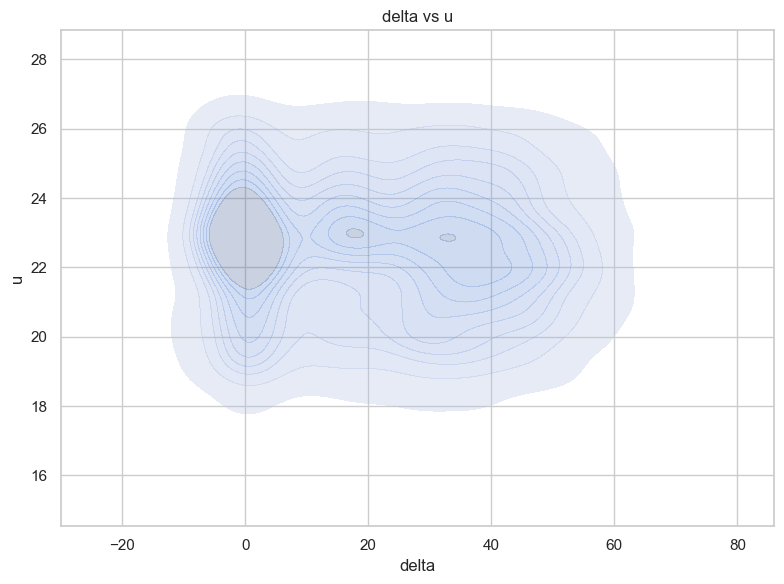

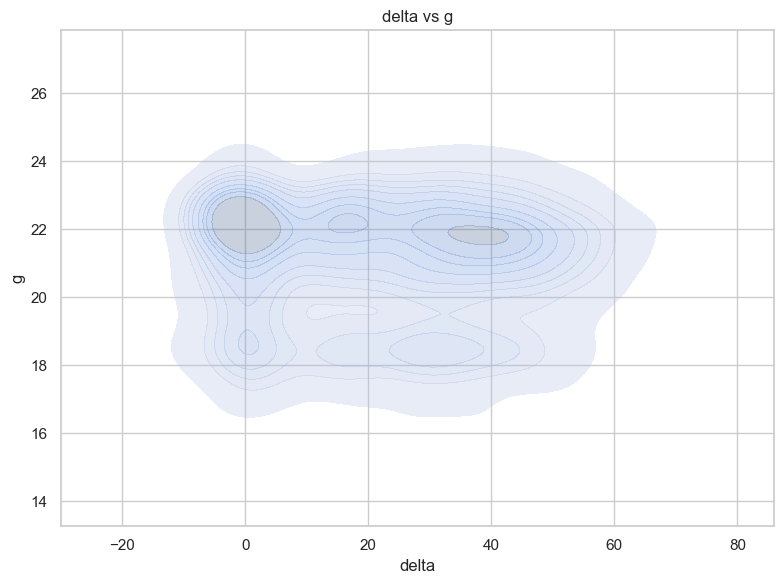

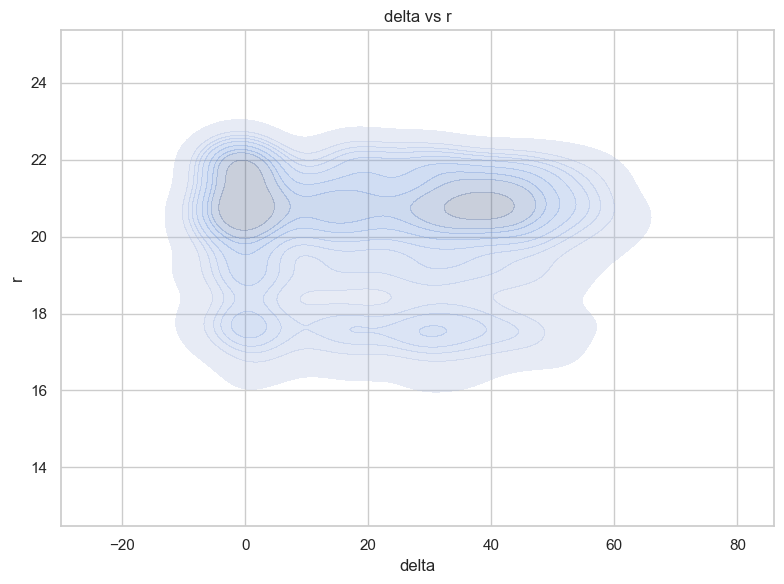

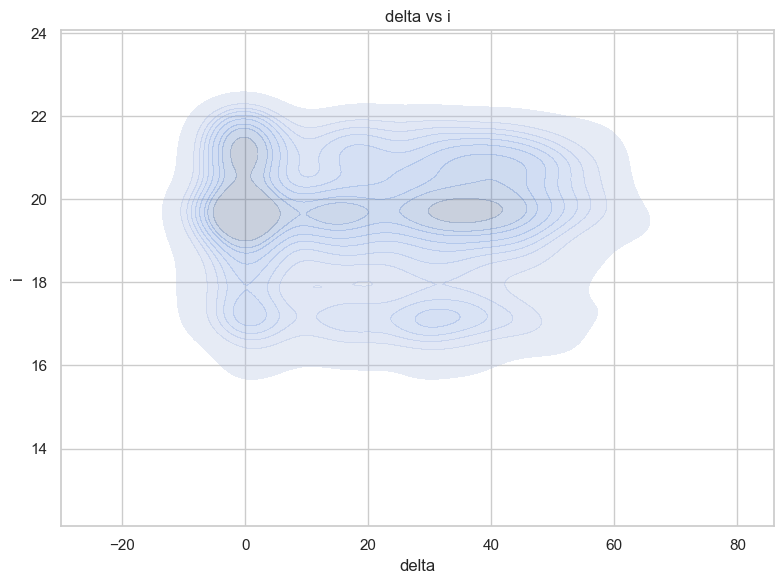

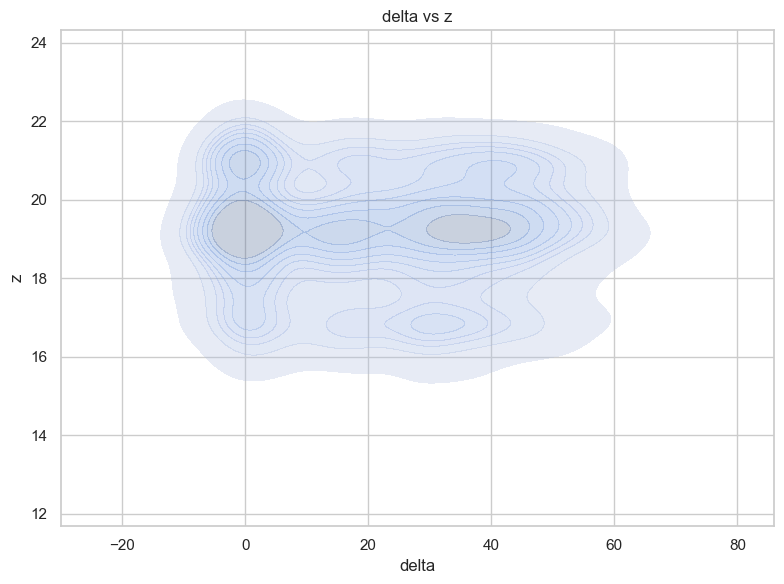

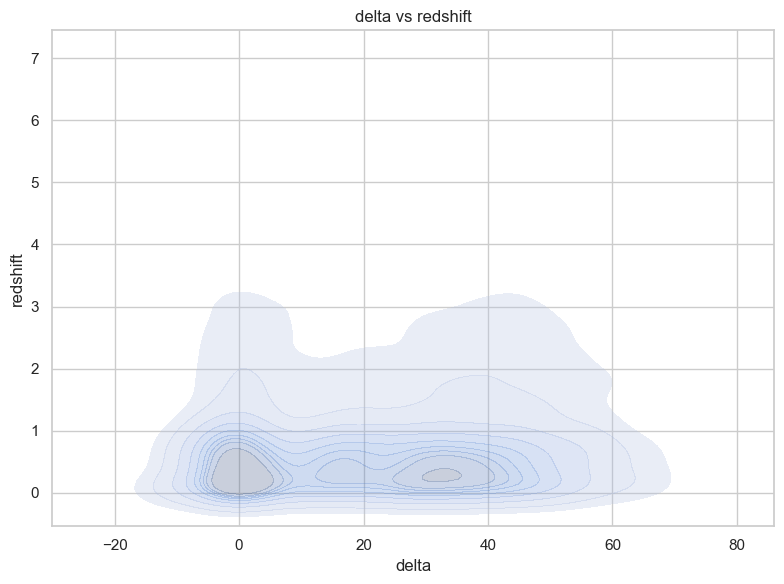

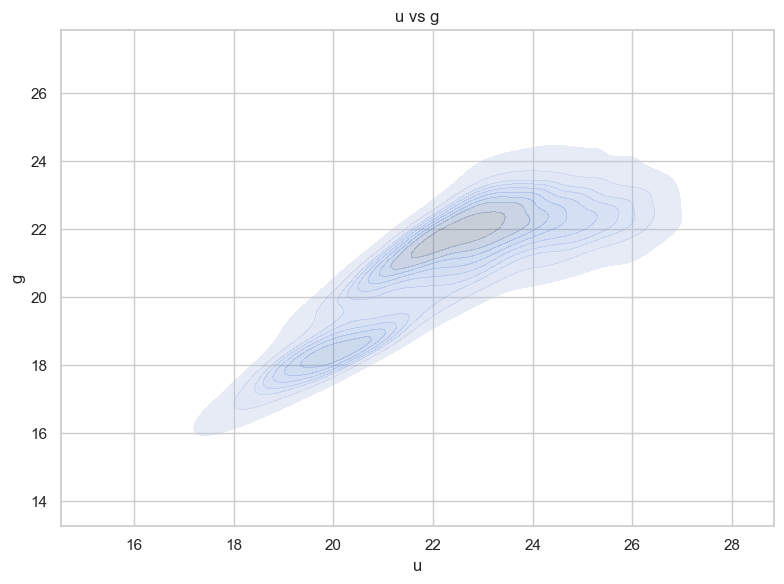

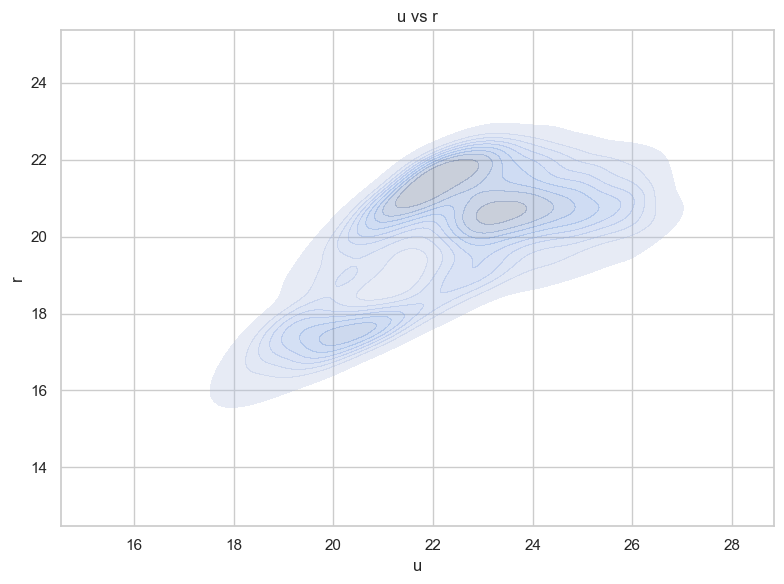

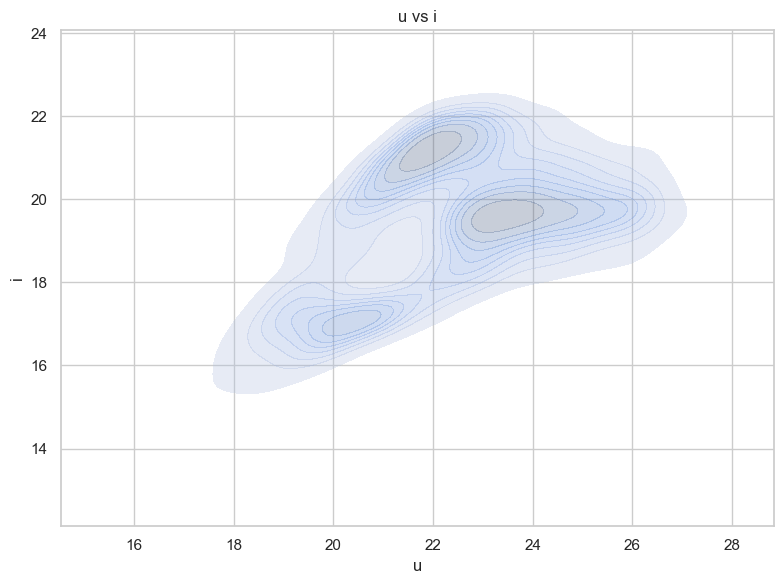

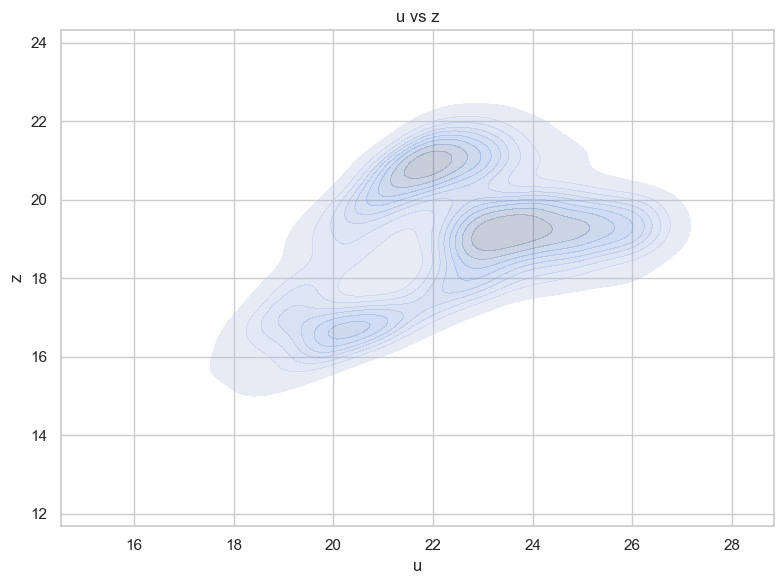

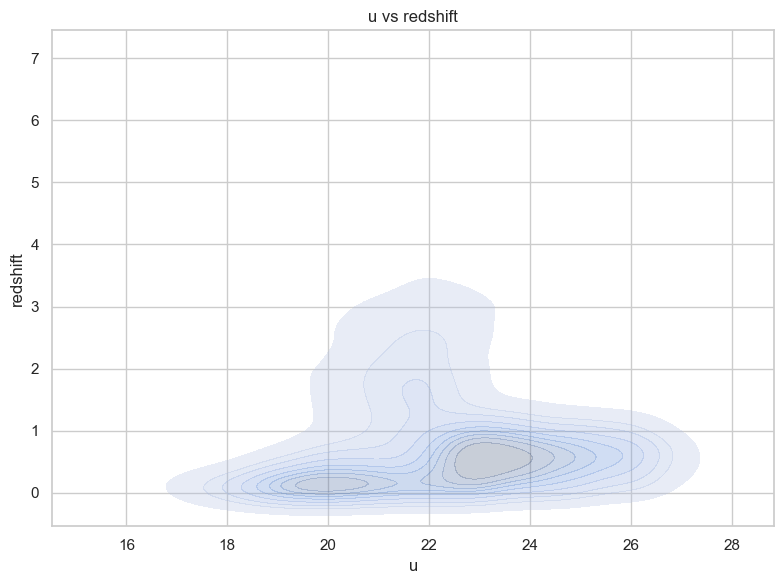

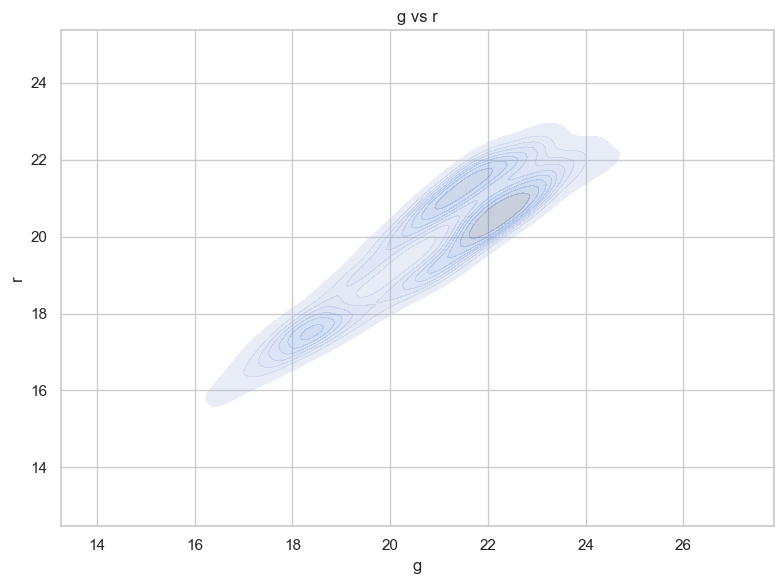

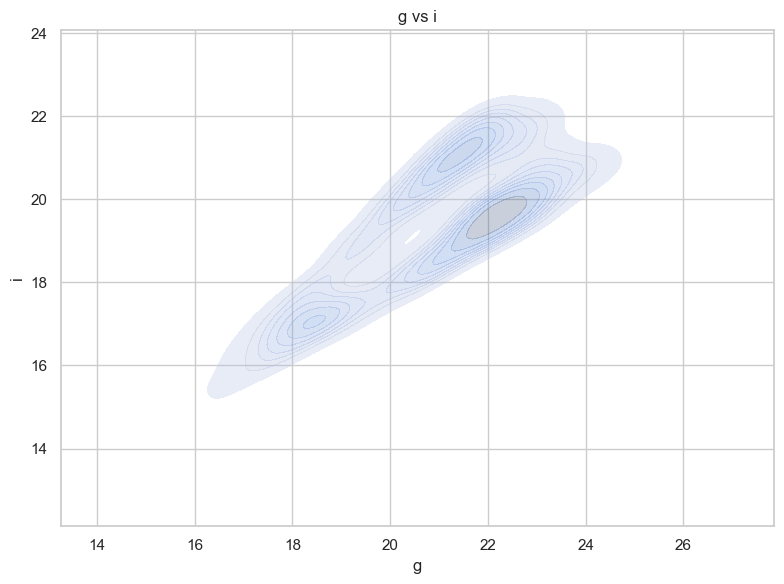

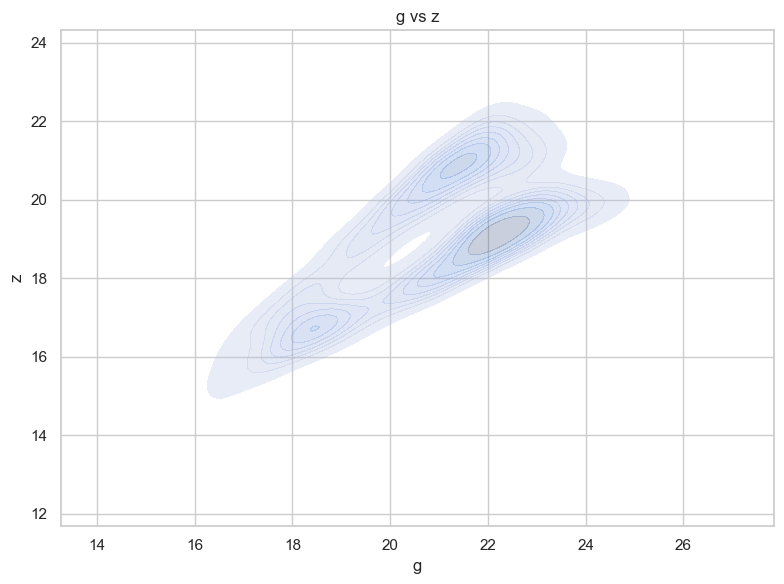

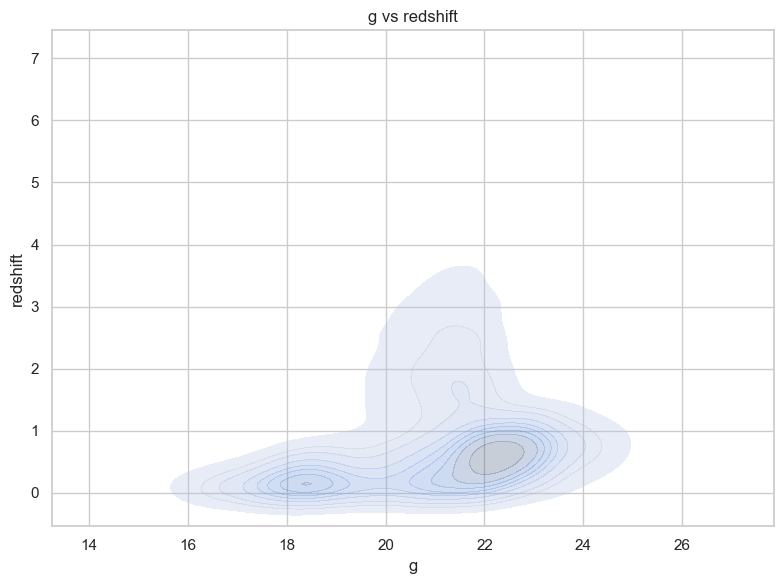

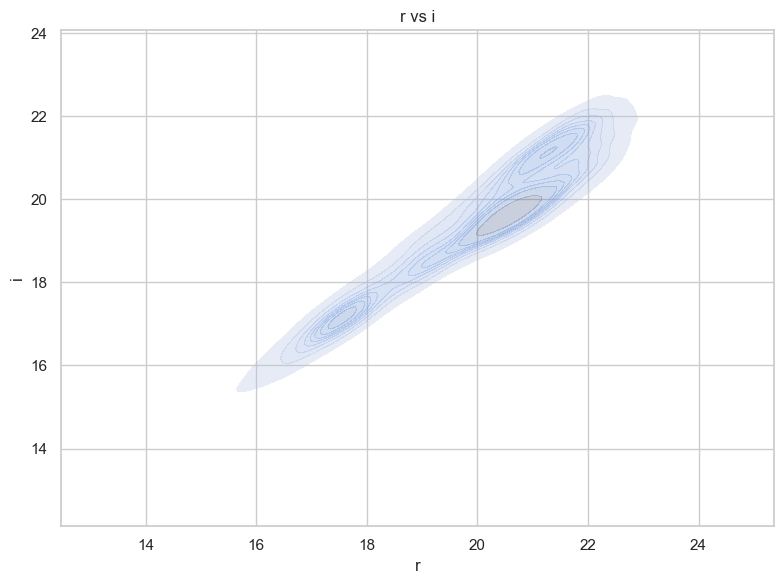

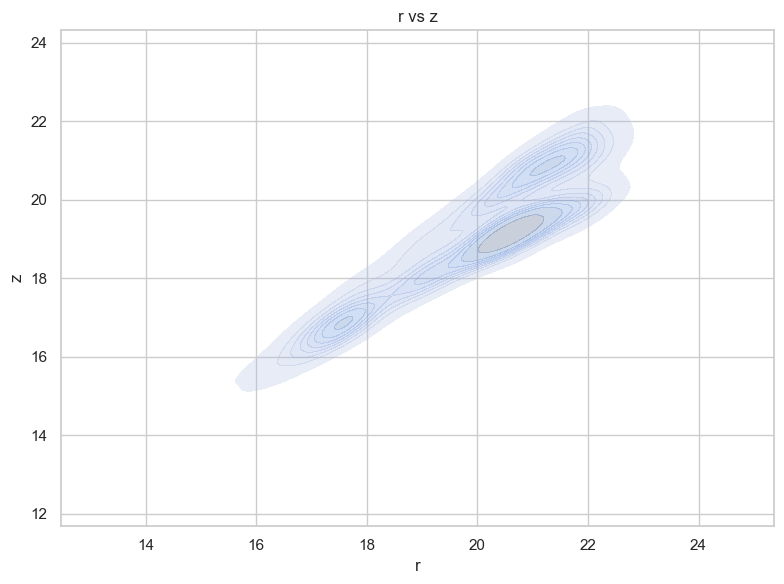

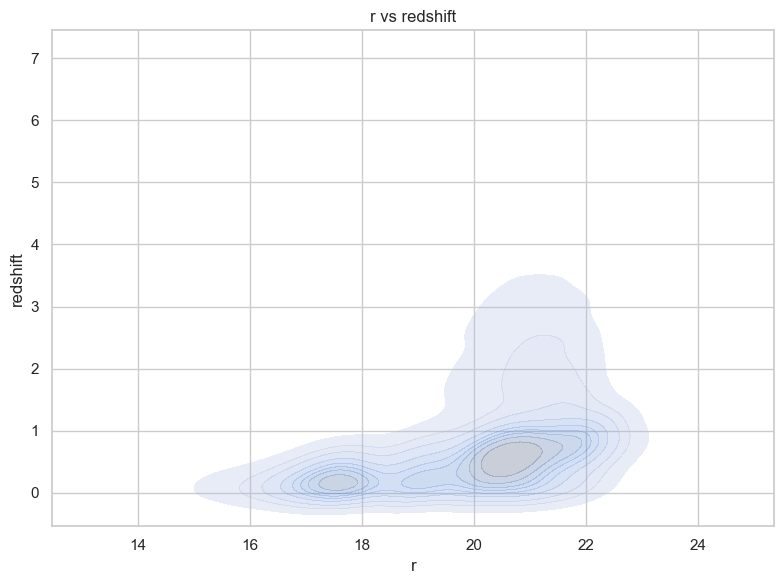

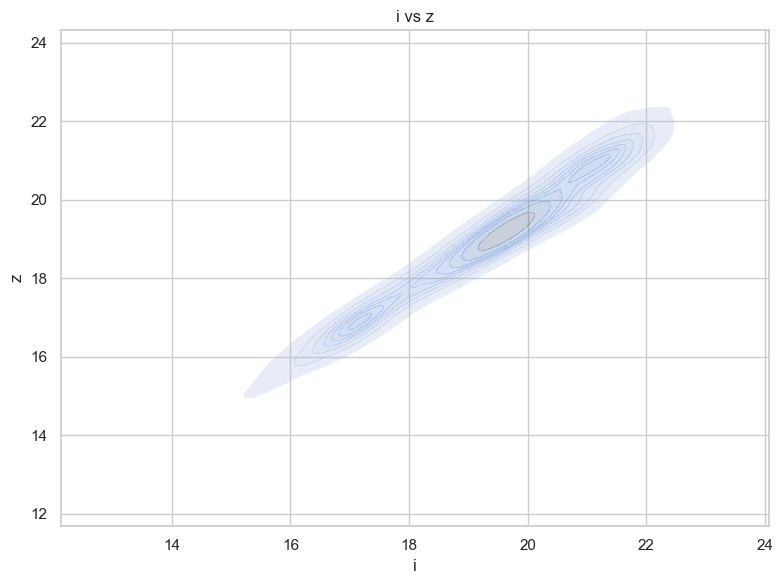

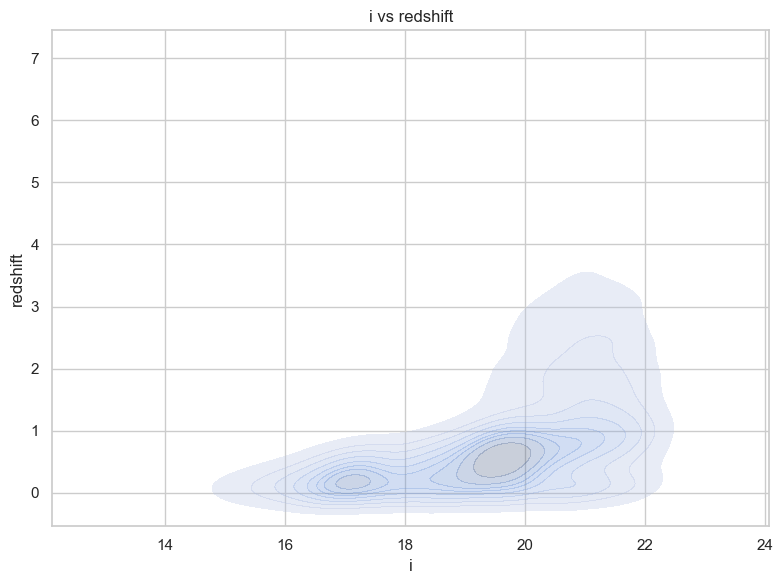

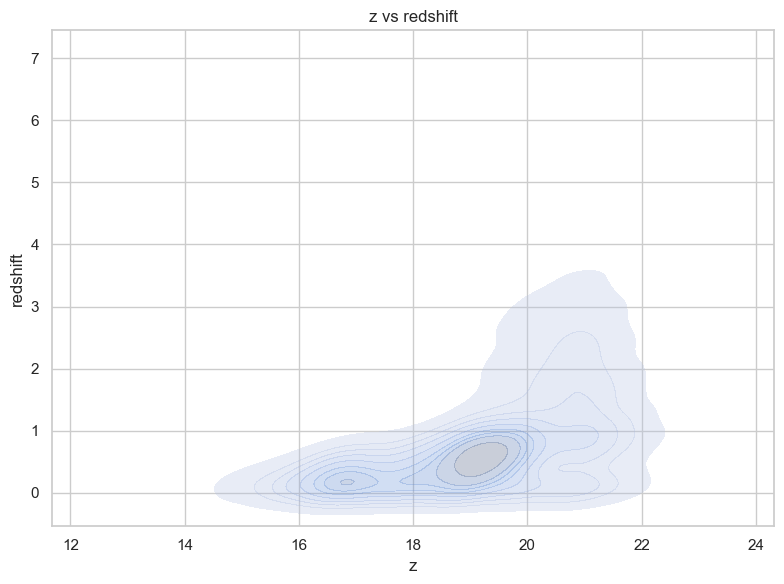

In [30]:
sample = df_test.sample(
    10000,
    random_state=42
)

for x_col, y_col in combinations(num_cols, 2):

    plt.figure(figsize=(8, 6))

    sns.kdeplot(
        data=sample,
        x=x_col,
        y=y_col,
        fill=True,
        alpha=0.3
    )

    plt.title(f"{x_col} vs {y_col}")

    plt.tight_layout()
    plt.show()

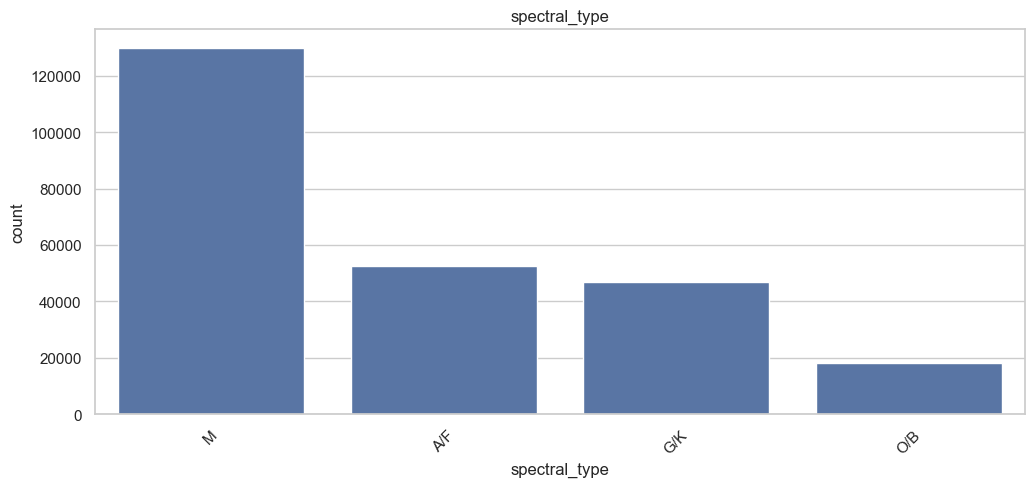

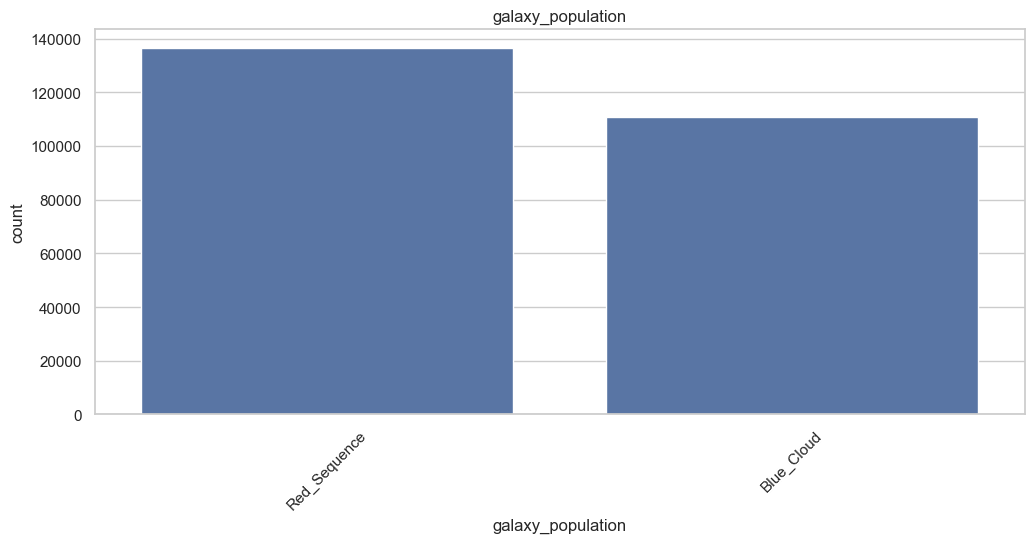

In [31]:
for col in ["spectral_type","galaxy_population"]:

    plt.figure(figsize=(12,5))

    sns.countplot(
        data=df_test,
        x=col,
        order=df_test[col].value_counts().index)

    plt.xticks(rotation=45)
    plt.title(col)
    plt.show()

In [32]:
outlier_summary = []

for col in num_cols:

    Q1=df_test[col].quantile(0.25)
    Q3=df_test[col].quantile(0.75)

    IQR=Q3 - Q1

    lower=Q1 - 1.5*IQR
    upper=Q3 + 1.5*IQR

    outliers = ((df_test[col] < lower) | (df_test[col] > upper)).sum()

    outlier_summary.append([
        col,
        outliers,
        round(outliers / len(df_test) * 100,2)])

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=[
        "Feature",
        "Outlier Count",
        "Outlier %"
    ]
)

display(outlier_df)

,Feature,Outlier Count,Outlier %
0,id,0,0.00
1,alpha,0,0.00
2,delta,0,0.00
3,u,155,0.06
4,g,1307,0.53
5,r,814,0.33
6,i,586,0.24
7,z,653,0.26
8,redshift,22648,9.15
